<a href="https://colab.research.google.com/github/ngzhiwei517/HDB-Resale-Price-Analysis-project/blob/main/SC3021_Group_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Group 4 (FDAE)

1. HAU JIA QI
2. NG ZHI WEI
3. TOH EN QI

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

import numpy as np
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LinearRegression
from sklearn.tree            import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics         import r2_score, mean_squared_error
from xgboost                 import XGBRegressor

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np


# **How does Air Quality and Distance to Public Facilities Affect Property Prices in Singapore?**

## **Introduction**


For Singaporeans, housing is not merely a means of material shelter, but also something they strive for throughout their lives, and in a sense, a source of emotional support. Naturally, fluctuations in housing prices are a constant concern in their daily lives. Whether they are working hard to buy a home or considering selling or renting it out, price increases are crucial. Our group has observed these price fluctuations, but the reasons behind them remain unknown. Therefore, we intend to explore and compare the innfluence of these two factors -- air quality and access to key facilities -- on HDB resale prices.

Given the limited land area, most housing in Singapore is in the form of high-rise apartments, primarily HDB flats. The Housing & Development Board (HDB) in Singapore is the national public housing authority responsible for providing affordable and quality housing to the nation's residents.

## **Deriving the Problem Statement**

In Singapore, the majority of people live in HDB flats, which are public housing units provided by the Housing and Development Board (HDB). Approximately 77.4% of residents live in HDB flats, with the most common type being four-room flats. In exploring the factors contributing to rising housing prices in Singapore,we focus on two potential drivers: locational amenities and environmental quality.
1. Air Quality: Singapore's air quality varies significantly across different regions and at different times due to factors such as cross-border smog, industrial activities, and traffic patterns.According to WHO research, air pollutants (PM2.5, PM10, nitrogen dioxide, etc.) can have serious health effects.

2. Access to Facilities: In real estate pricing, distance to public facilities (such as MRT stations, hospitals, and schools) is generally considered a significant factor influencing property prices. Generally speaking, residences closer to major transportation hubs or amenities tend to be more popular with homebuyers due to shorter commutes and greater convenience, potentially resulting in higher transaction prices.

This report primarily explores how differences in air quality across different areas of Singapore and proximity to facilities affect the price of HDB flats.


## **Hypothesis/Analysis Goal (Ask)**


In this report, we hypothesize that even if Singapore's air quality remains within safe limits, regional differences in air quality are correlated with HDB resale prices. We also assume that HDB flats located closer to key public facilities (such as MRT stations, hospitals, and schools) tend to command higher resale prices due to greater accessibility and convenience. In summary, this descriptive and correlational analysis will explore the following questions:

1. Do areas with persistently high PSI/PM2.5 levels exhibit lower HDB resale prices?

2. How does accessibility to key amenities (MRT/LRT stations, shopping centres, schools, healthcare) relate to resale prices?

3. What is the relative contribution of environmental and accessibility factors compared to traditional housing attributes (flat size, storey range, remaining lease) in explaining price variation?

Through detailed analysis of these questions, we hope to gain a more comprehensive understanding of the potential impact of air quality and distances on Singapore's HDB resale market. The goal is to quantify the relative contribution of environmental and accessibility factors in explaining HDB resale prices, beyond traditional housing attributes.

Meanwhile, this is primarily a regression and exploratory analysis problem, where resale price is the target variable and air quality, accessibility measures, and housing characteristics are explanatory variables.
Model performance will be evaluated using standard hypothesis testing and prediction metrics, including:

* R-squared: proportion of price variation explained by the model
* Mean Squared Error (MSE): predictive accuracy of resale price estimates



##**Stakeholders**



It is important to identify which groups of the public would benefit from our findings, so that we can phrase and present out findings to them, such that they can make better and more informed data-driven decisions when it comes to planning or getting a new home. The following are the stakeholders we have identified:
1. Current homeowners: In the event they want to sell their house, they will have a clearing understanding on how to price their flats

2. Future homeowners: They will have a clearing understanding on which region and area of Singapore is within their budget and at the same time, having better air quality, rather than only understanding the adverse effects of poor air quality after moving in.

3. Property agents: With the knowledge, they can advice and recommend their clients the most suitable flat and also come up with better pricing stratgies.

4. Government agencies (policy makers and urban planners): Having the insights to better managed to air quality as well as the flat prices. For areas with extremely poor air quality, follow-up actions should be done to investigate and improve the surrounding environments

5. Anyone who is interested to learn about how air quality affects the housing prices, or in general for public who are keen to study about housing prices in Singapore


## **Data Source Identification (Prepare)**

###Requirement analysis:

To solve the problem, we would need the following data:
1. Historical data on the resale prices of HDB flats in various towns of Singapore over the years
    - identifying trends and how environmental and accessibility factors affects the price
2. Historical Pollutant Standards Index (PSI) over the years
    - understanding the air quality of different regions and how it might affect the flat price
3. Characteristics of the flats (eg. flat type, storey range and remaining leasing)
    - analysing how traditional housing attributes affects the flat price
4. Locations of amenities (MRT and LRT, hospitals and schools)
    - using the proximity of such amenities to the flats to analyse its influence on flat prices
5. Region in which the town is located
    - North, South, East, West, Central
    - to match the towns with the regions, allowing for comparisons between various flats

We will be analysing and linking the data by town (eg. Jurong East, Boon Lay), with the exception of the PSI data as such data are region-based. Hence, other than knowing the towns of the various HDB flats, identifying the region is needed, to link the price of resale flats with the air quality.


To ensure a comprehensive analysis, we have chosen datasets that covers a range of years and locations. In the attempt to reflect the current resale flat market and make relevent decisions,
we will be using data from 2021 to 2024. This is also the period after the COVID-19 pandemic, when some preference and priorities may have shifted.

Given that housing purchase decisions are influenced by longer-term environmental conditions rather than short-term fluctuations, air quality data will be aggregated at the monthly level.

###List of considered sources:

We mark the final source selection datasets with an *.

* **Property Price Data**
* [Resale Flat Prices (Based on Registration Date) from Jan 2017 onwards(DS1)*](https://data.gov.sg/datasets/d_8b84c4ee58e3cfc0ece0d773c8ca6abc/view )


* **Air Quality Data**
* [Historical Pollutant Standards Index (PSI) 2021 (DS2)*](https://data.gov.sg/datasets/d_05b35c51664e1bb6f4dcd78478ae1abe/view)
* [Historical Pollutant Standards Index (PSI) 2022 (DS3)*](https://data.gov.sg/datasets/d_d3fb32451d63dc48dc425146ec014516/view)
* [Historical Pollutant Standards Index (PSI) 2023 (DS4)*](https://data.gov.sg/datasets/d_10501b71361f97dbbbab82095406c9c5/view)
* [Historical Pollutant Standards Index (PSI) 2024 (DS5)*](https://data.gov.sg/datasets/d_9213cd2e4631f7148ab5932a10df9958/view)

* **Location/Amenities Data**
* [Singapore Train Station Coordinates (DS6)*](https://www.kaggle.com/datasets/yxlee245/singapore-train-station-coordinates)
* [Hospitals with Coordinates (DS7)](https://www.kaggle.com/datasets/muhdirshath/hospitals-in-singapore)

* **Education Amenities**
* [General information of schools (DS8)*](https://data.gov.sg/datasets/d_688b934f82c1059ed0a6993d2a829089/view)

* **Geographic Mapping Data**
* [Singapore City Geo-Coordinates (DS9)*](https://www.kaggle.com/datasets/shymammoth/singapore-city-geo-coordinates-more-reliable)

##**Data Exploration**

In the following, we explored and justified for the selection of each dataset.

### DS1: HDB Resale Flat Prices

**Description**:
This dataset was extracted from Singapore's open data portal, data.gov.sg, and contains HDB resale flat transaction records from January 2017 onwards. It includes key attributes such as the transaction month, town, flat type, block, street name, storey range, floor area (sqm), flat model, lease commencement date, remaining lease, and resale price — covering all the housing characteristics we identified as requirements in our problem formulation.

This dataset directly addresses our core requirement of having historical resale price data across different towns in Singapore. The town column allows us to link resale prices to specific locations, which is essential for comparing prices across regions and eventually joining with our air quality and amenity datasets.

Although the dataset spans from January 2017 onwards, for our analysis we will be filtering to 2021–2024 during the data preparation stage. This allows us to focus on the post-COVID period, where housing preferences and priorities may have shifted, and to align with the time range of our PSI air quality data.

#### Step 1: Load and preview the dataset

We first load the dataset using pandas and preview the first few rows to understand its structure and ensure that the data has been loaded correctly.

In [ ]:
# Load dataset
resale = pd.read_csv('/content/Resale flat price 2017-26.csv')

resale.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


This step allows us to verify that the dataset has been imported successfully and to observe the format of each column. Next, we examine the structure of the dataset to understand the number of rows, columns, and data types.

#### Step 2: Check shape and column info

In [ ]:
# Check number of rows, columns and data types
resale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224000 entries, 0 to 223999
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                224000 non-null  object 
 1   town                 224000 non-null  object 
 2   flat_type            224000 non-null  object 
 3   block                224000 non-null  object 
 4   street_name          224000 non-null  object 
 5   storey_range         224000 non-null  object 
 6   floor_area_sqm       224000 non-null  float64
 7   flat_model           224000 non-null  object 
 8   lease_commence_date  224000 non-null  int64  
 9   remaining_lease      224000 non-null  object 
 10  resale_price         224000 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 18.8+ MB


The dataset contains 224,000 entries and 11 columns. Most columns are stored as object types (categorical information such as town, flat type, and street name), while numerical variables such as floor_area_sqm and resale_price are stored as float values. The lease_commence_date column is stored as an integer representing the year the lease started.

This step helps confirm that the dataset contains the expected variables and that the data types are appropriate for further analysis. We then check for missing values across all columns to ensure data completeness.

#### Step 3:Check for missing values

In [ ]:
# Count missing values per column
resale.isnull().sum()

,0
month,0
town,0
flat_type,0
block,0
street_name,0
storey_range,0
floor_area_sqm,0
flat_model,0
lease_commence_date,0
remaining_lease,0


The results show that all columns contain zero missing values, indicating that the dataset is complete and does not require imputation or data cleaning for missing entries. Next, we examine the number of distinct values in each column to understand the diversity of the data. This information helps us understand how categorical variables are distributed and whether they are suitable for grouping or aggregation during analysis.

#### Step 4: Cardinalities — distinct values per column

In [ ]:
# Check number of unique values per column
resale.nunique()

,0
month,109
town,26
flat_type,7
block,2748
street_name,576
storey_range,17
floor_area_sqm,187
flat_model,21
lease_commence_date,56
remaining_lease,696


The dataset spans 109 distinct months, confirming broad temporal coverage. There are 26 unique towns, aligning well with our requirement to compare resale prices across different locations in Singapore. resale_price has 4,576 distinct values, reflecting the wide continuous variation expected of a regression target variable. storey_range has only 17 distinct categories, and flat_type just 7 — both of which can be treated as ordinal or categorical features after numeric extraction and encoding

#### Step 5: Summary statistics

In [ ]:
# Summary statistics for numeric columns
resale.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,224000.000000,224000.000000,2.240000e+05
mean,96.751149,1996.455982,5.255811e+05
std,24.015345,14.310548,1.871231e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.860750e+05
50%,93.000000,1997.000000,4.950000e+05
75%,112.000000,2012.000000,6.300000e+05
max,366.700000,2021.000000,1.658888e+06


The average resale price is approximately SGD 525,581, with values ranging widely from SGD 140,000 to SGD 1,658,888. This large spread — with a standard deviation of SGD 187,123 — suggests that resale prices are heavily influenced by multiple factors, motivating our multivariate regression approach. floor_area_sqm ranges from 31 to 366.7 sqm with a mean of 96.75 sqm, consistent with typical HDB flat sizes. lease_commence_date spans from 1966 to 2021, reflecting the mix of older and newer flats across the dataset. We next examine the distribution of resale transactions across towns.

#### Step 6: Distribution of resale transactions by town

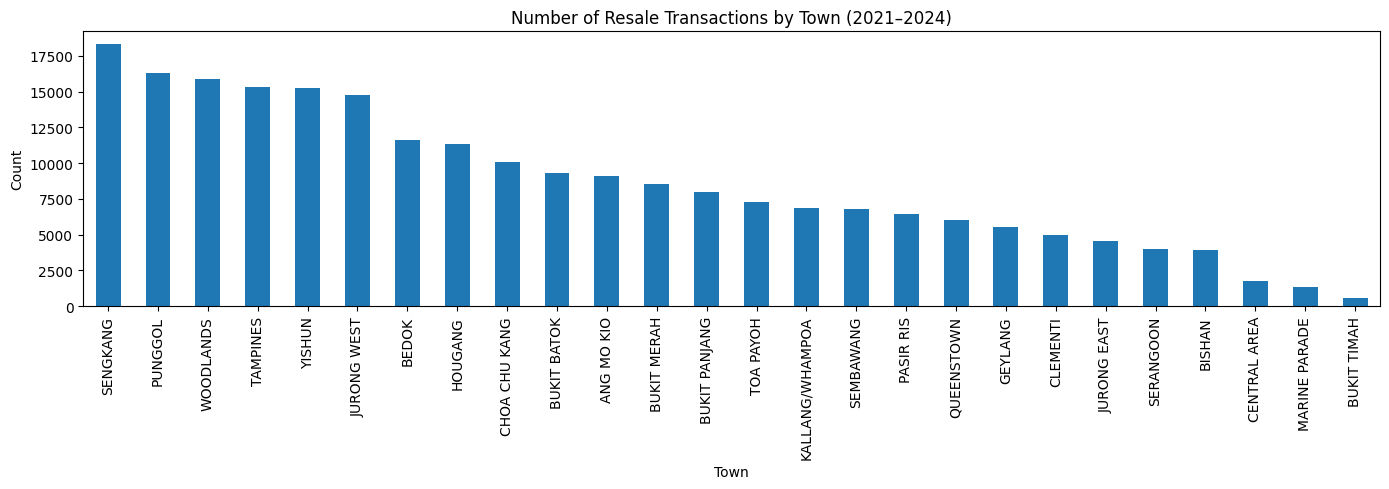

In [ ]:
resale['town'].value_counts().plot(kind='bar', figsize=(14,5), title='Number of Resale Transactions by Town (2021–2024)')
plt.xlabel('Town')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The chart shows that towns such as Sengkang, Punggol, Woodlands, Tampines, and Yishun have the highest number of resale transactions between 2021 and 2024. In contrast, towns such as Bukit Timah, Marine Parade, and Central Area have significantly fewer transactions.

This distribution likely reflects differences in housing supply and population density across towns, as well as the number of available HDB flats in each location. Next,we examine how resale prices vary across different storey ranges.

#### Step 7: Storey range vs average resale price

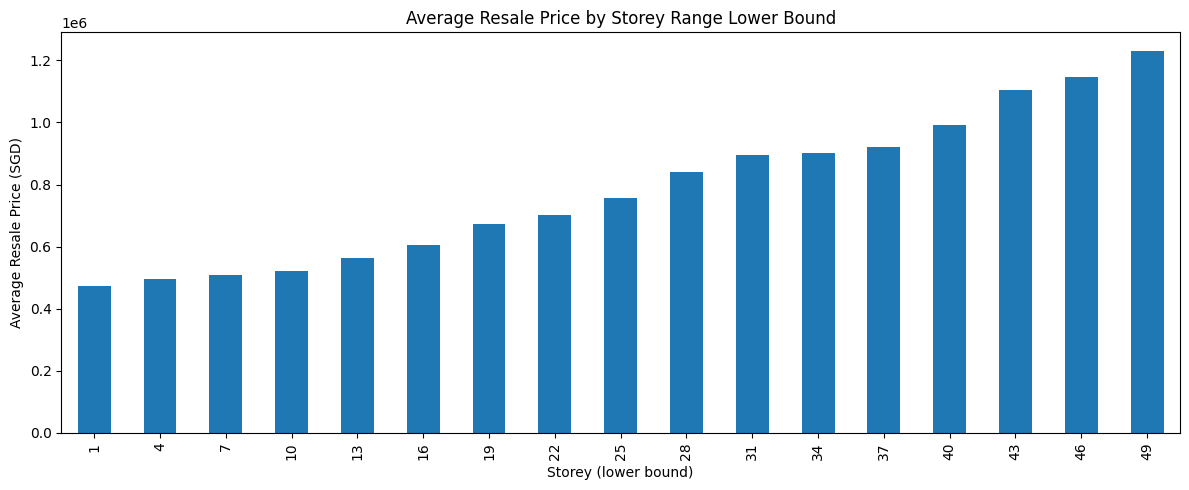

In [ ]:
# Extract storey lower bound for ordering
resale['storey_low'] = resale['storey_range'].str.split(' TO ').str[0].astype(int)

resale.groupby('storey_low')['resale_price'].mean().plot(
    kind='bar', figsize=(12,5),
    title='Average Resale Price by Storey Range Lower Bound'
)
plt.xlabel('Storey (lower bound)')
plt.ylabel('Average Resale Price (SGD)')
plt.tight_layout()
plt.show()

The results show a clear upward trend, where flats located on higher storeys tend to have higher average resale prices. This may be due to several factors, such as better views, reduced noise, improved ventilation, and stronger buyer preferences for higher-floor units.

This relationship suggests that storey level is an important housing characteristic influencing resale prices, and it may be included as a relevant feature in further analysis. Next, we examine the relationship between flat type and the average resale price.

#### Step 8: Flat type vs average resale price

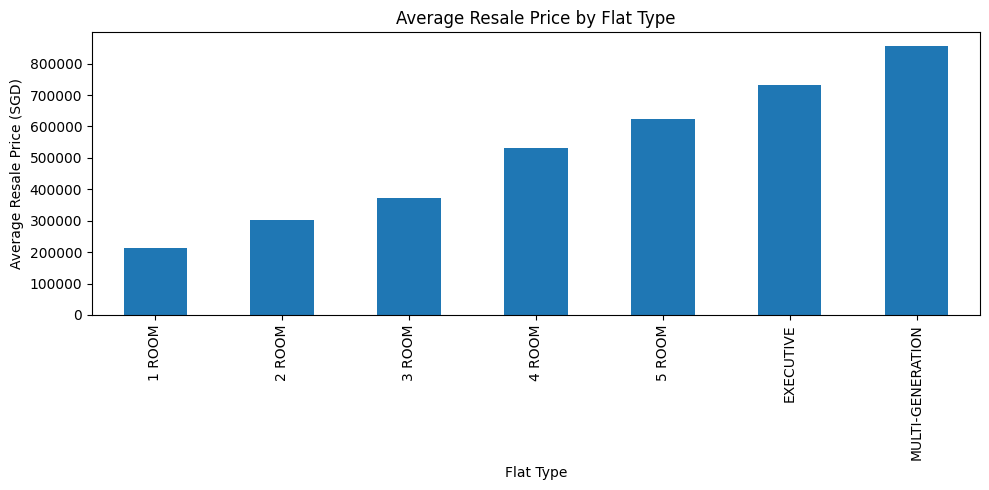

In [ ]:
resale.groupby('flat_type')['resale_price'].mean().sort_values().plot(
    kind='bar', figsize=(10,5),
    title='Average Resale Price by Flat Type'
)
plt.xlabel('Flat Type')
plt.ylabel('Average Resale Price (SGD)')
plt.tight_layout()
plt.show()

The chart shows a clear upward trend in average resale prices as the flat type increases in size. Smaller flats such as 1-room and 2-room units have the lowest average resale prices, while larger units such as Executive and Multi-Generation flats have significantly higher average prices.

For example, 1-room flats have an average resale price of approximately SGD 210,000, while Multi-Generation flats exceed SGD 850,000 on average. This pattern is expected because larger flats typically offer more living space and rooms, making them more suitable for larger households.Additionally, larger flat types tend to be less common and may be located in more mature towns, which can also contribute to higher resale values.

Overall, this analysis suggests that flat type is a strong determinant of resale price, and it will likely be an important variable when analysing housing price variations across different towns in Singapore.

#### Step 9: Remaining lease vs average resale price

Last, we analyse the relationship between remaining lease and the average resale price of HDB flats. Remaining lease refers to the number of years left on the flat’s lease and is an important factor influencing housing value.

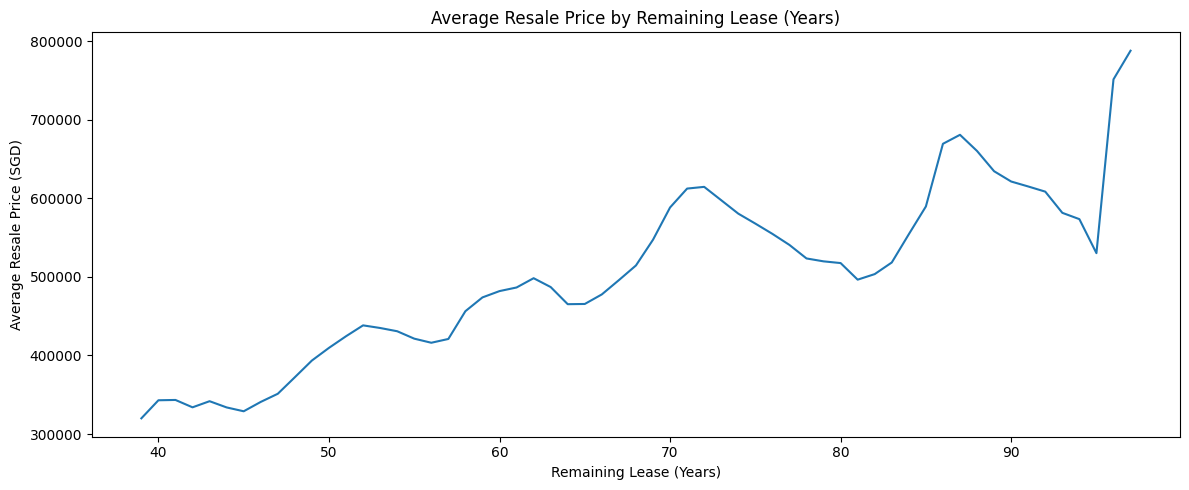

In [ ]:
# Extract numeric years from remaining_lease string e.g. "61 years 04 months"
resale['remaining_lease_years'] = resale['remaining_lease'].str.extract(r'(\d+)\s*year').astype(float)

resale.groupby('remaining_lease_years')['resale_price'].mean().plot(
    figsize=(12,5),
    title='Average Resale Price by Remaining Lease (Years)'
)
plt.xlabel('Remaining Lease (Years)')
plt.ylabel('Average Resale Price (SGD)')
plt.tight_layout()
plt.show()

The chart shows a generally increasing trend, where flats with longer remaining leases tend to have higher average resale prices. Flats with around 40 years of remaining lease have lower average prices, while flats with 90 years or more remaining lease have significantly higher prices.This suggests that remaining lease is an important factor affecting resale prices, as buyers typically prefer flats with longer lease durations.

#### Data Quality Assessment

**Positively assessed** — Completeness and source reliability: The dataset contains 224,000 entries with zero missing values across all 11 columns, indicating that all variables are fully recorded. As the dataset is obtained from data.gov.sg, Singapore's official open data portal maintained by the government, it is expected to meet high standards of reliability and accuracy, making it a trustworthy source for our analysis.


**Problematically assessed** — String-encoded numerical columns requiring extraction: Several columns that are analytically important are stored as strings rather than usable numeric values. The storey_range column is stored in the format "10 TO 12", and remaining_lease is stored as "61 years 04 months" — both requiring regex extraction before they can be used as numeric features in our regression model. Additionally, the month column is stored as a string in "YYYY-MM" format and will need to be converted to datetime. These formatting issues must be resolved during data structuring before any meaningful analysis can be performed.

#### Conclusion

DS1 is the core dataset of our analysis, providing comprehensive HDB resale transaction records across Singapore from 2017 to 2026. It is complete, reliable and directly addresses our requirement for historical resale price data across different towns. Key points for subsequent steps:


**Data Structuring:**

* Filter rows to retain only 2021–2024 transactions, aligning with our PSI air quality data time range
* Convert month from string to datetime format and extract year and month_num as separate columns
Extract numeric storey lower bound from storey_range (e.g. "10 TO 12" → 10) using string splitting
* Extract numeric remaining lease years from remaining_lease (e.g. "61 years 04 months" → 61) using regex
* Drop columns not needed for analysis: block, street_name, flat_model



**Data Enriching:**

* The town column will serve as the primary join key to link resale transactions with school count from DS8, nearest MRT distance computed using DS6 and DS9, and PSI region mapping from DS9
* Each transaction will be tagged with its corresponding monthly PSI and PM2.5 readings by matching town → region (via DS9) and year-month (via DS2–DS5)

### DS2–DS5: Historical Pollutant Standards Index (PSI), 2021–2024

**Description:** The PSI datasets were extracted from Singapore's open data portal, data.gov.sg. Four separate annual datasets were used — covering 2021, 2022, 2023 and 2024 — as the data is published year by year. Each dataset contains hourly pollutant readings across five regions in Singapore (North, South, East, West and National), with measurements including PM2.5, PM10, ozone (O3), carbon monoxide (CO), sulphur dioxide (SO2), nitrogen dioxide (NO2), and the overall PSI index. This directly addresses our requirement for air quality data across different regions of Singapore over the 2021–2024 period.

Since housing purchase decisions are influenced by longer-term environmental conditions rather than short-term fluctuations, we will be aggregating the PSI readings to the monthly level during data structuring. We will also retain five regional readings (North, South, East, West, Central). Additionally, region_id will be dropped as it is simply a coded duplicate of the region column (e.g. rSO = South) and adds no analytical value.

#### Step 1: Load and preview the datasets

We first load the PSI datasets and preview the first few rows to understand their structure and confirm that the data has been imported correctly. Each dataset contains hourly air quality readings across different regions in Singapore, including pollutants such as PM2.5, PM10, ozone (O₃), carbon monoxide (CO), sulphur dioxide (SO₂), nitrogen dioxide (NO₂), and the overall PSI index.

In [ ]:
# Load all four PSI datasets
psi_2021 = pd.read_csv('/content/HistoricalPollutantStandardsIndexPSI2021.csv')
psi_2022 = pd.read_csv('/content/HistoricalPollutantStandardsIndexPSI2022.csv')
psi_2023 = pd.read_csv('/content/HistoricalPollutantStandardsIndexPSI2023.csv')
psi_2024 = pd.read_csv('/content/HistoricalPollutantStandardsIndexPSI2024 (1).csv')

# Combine into one dataframe
psi = pd.concat([psi_2021, psi_2022, psi_2023, psi_2024], ignore_index=True)

# Preview top 5 rows
psi.head()

,date,timestamp,update_timestamp,region,region_id,location_longitude,location_latitude,pm10_twenty_four_hourly,pm10_sub_index,pm25_twenty_four_hourly,pm25_sub_index,o3_eight_hour_max,o3_sub_index,co_eight_hour_max,co_sub_index,so2_sub_index,so2_twenty_four_hourly,no2_one_hour_max,psi_twenty_four_hourly,psi_three_hourly
0,1/1/2021,2021-01-01T00:00:00+08:00,2021-01-01T00:08:52+08:00,south,rSO,103.82,1.29587,31.0,31.0,16.0,55.0,32.0,14.0,0.71,7.0,3.0,4.0,14.0,55.0,NaN
1,1/1/2021,2021-01-01T00:00:00+08:00,2021-01-01T00:08:52+08:00,north,rNO,103.82,1.41803,28.0,28.0,13.0,52.0,51.0,21.0,0.51,5.0,2.0,3.0,3.0,52.0,NaN
2,1/1/2021,2021-01-01T00:00:00+08:00,2021-01-01T00:08:52+08:00,east,rEA,103.94,1.35735,36.0,36.0,16.0,55.0,35.0,15.0,0.58,6.0,2.0,3.0,10.0,55.0,NaN
3,1/1/2021,2021-01-01T00:00:00+08:00,2021-01-01T00:08:52+08:00,central,rCE,103.82,1.35735,29.0,29.0,12.0,50.0,22.0,9.0,0.38,4.0,2.0,3.0,8.0,50.0,NaN
4,1/1/2021,2021-01-01T00:00:00+08:00,2021-01-01T00:08:52+08:00,west,rWE,103.70,1.35735,25.0,25.0,9.0,37.0,14.0,6.0,0.53,5.0,3.0,6.0,17.0,37.0,NaN


Next, we examine the dataset structure to understand the number of rows, columns, and data types.

#### Step 2: Check shape and column info

In [ ]:
psi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202158 entries, 0 to 202157
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     202158 non-null  object 
 1   timestamp                202158 non-null  object 
 2   update_timestamp         202158 non-null  object 
 3   region                   202158 non-null  object 
 4   region_id                202158 non-null  object 
 5   location_longitude       202158 non-null  float64
 6   location_latitude        202158 non-null  float64
 7   pm10_twenty_four_hourly  191979 non-null  float64
 8   pm10_sub_index           191979 non-null  float64
 9   pm25_twenty_four_hourly  191979 non-null  float64
 10  pm25_sub_index           191979 non-null  float64
 11  o3_eight_hour_max        191929 non-null  float64
 12  o3_sub_index             191710 non-null  float64
 13  co_eight_hour_max        161071 non-null  float64
 14  co_s

The dataset contains 202,158 entries and 20 columns, with most pollutant measurements stored as float values and time-related variables stored as object types. Columns such as pm10_twenty_four_hourly, pm25_twenty_four_hourly, o3_eight_hour_max, and psi_twenty_four_hourly represent numerical air quality measurements.

This step confirms that the dataset includes the expected pollutant indicators required for analysing air quality trends across regions in Singapore. Next, we check for missing values across all columns.

#### Step 3: Check for missing values

In [ ]:
psi.isnull().sum()

,0
date,0
timestamp,0
update_timestamp,0
region,0
region_id,0
location_longitude,0
location_latitude,0
pm10_twenty_four_hourly,10179
pm10_sub_index,10179
pm25_twenty_four_hourly,10179


The results show that several pollutant variables contain missing values, particularly co_eight_hour_max and other pollutant measurements. The column psi_three_hourly contains entirely missing values, indicating that it was not recorded in this dataset.

Since the psi_twenty_four_hourly column already provides a comprehensive indicator of overall air quality, the psi_three_hourly column will be removed during data cleaning as it does not provide useful analytical information.

#### Step 4: Cardinalities — distinct values per column

In [ ]:
psi.nunique()

,0
date,1429
timestamp,33693
update_timestamp,33693
region,6
region_id,6
location_longitude,4
location_latitude,4
pm10_twenty_four_hourly,212
pm10_sub_index,187
pm25_twenty_four_hourly,159


The dataset spans 1,429 distinct dates, covering air quality readings from 2021 to 2024. The region column contains six categories, representing the geographical regions where air quality is monitored.

**Pollutant measurement variables contain a large number of distinct values, reflecting the continuous variation expected in environmental data.** This confirms that the dataset provides sufficient variability for analysing air quality patterns across regions and time.

#### Step 5: Summary statistics

In [ ]:
psi.describe()

,location_longitude,location_latitude,pm10_twenty_four_hourly,pm10_sub_index,pm25_twenty_four_hourly,pm25_sub_index,o3_eight_hour_max,o3_sub_index,co_eight_hour_max,co_sub_index,so2_sub_index,so2_twenty_four_hourly,no2_one_hour_max,psi_twenty_four_hourly,psi_three_hourly
count,202158.000000,202158.000000,191979.000000,191979.000000,191979.000000,191979.000000,191929.000000,191710.000000,161071.000000,191929.000000,191979.000000,191979.000000,191869.000000,191979.000000,0.0
mean,86.516667,1.130992,26.104838,26.074574,11.865214,44.235305,24.168458,10.260395,0.566866,4.997792,3.173060,5.101626,25.545436,44.184711,NaN
std,38.691587,0.507024,9.050904,8.912268,4.968354,12.164375,16.732579,7.151491,0.241644,1.868293,2.560246,4.089767,15.783443,12.147101,NaN
min,0.000000,0.000000,5.000000,5.000000,2.000000,7.000000,1.000000,0.715482,0.060000,1.000000,1.000000,1.000000,1.000000,12.000000,NaN
25%,103.700000,1.295870,19.000000,19.000000,8.000000,35.000000,12.000000,5.000000,0.400000,4.000000,2.000000,3.000000,14.000000,34.000000,NaN
50%,103.820000,1.357350,25.000000,25.000000,11.000000,46.000000,21.000000,9.000000,0.520000,5.000000,2.000000,4.000000,22.000000,46.000000,NaN
75%,103.820000,1.357350,32.000000,32.000000,14.000000,54.000000,33.000000,14.000000,0.670000,6.000000,4.000000,6.000000,34.000000,54.000000,NaN
max,103.940000,1.418030,139.000000,95.000000,63.000000,109.000000,176.000000,124.000000,3.460000,35.000000,56.000000,109.000000,632.000000,124.000000,NaN


The summary statistics show that the average PSI value is approximately 44, indicating that air quality in Singapore generally falls within the “Good” to “Moderate” range. However, the maximum PSI value reaches 124, suggesting occasional periods of poorer air quality.

Pollutant measurements such as PM10, PM2.5, and O₃ also show variation across the dataset, indicating fluctuations in air pollution levels over time and across regions. These variations provide useful information for analysing environmental conditions that may influence housing preferences and urban living conditions.

#### Step 6: Distribution of PSI readings by region

Given the summary statistics above show regional variation in PSI readings, we plot the average 24-hour PSI by region to better visualise these differences across Singapore's five regions.

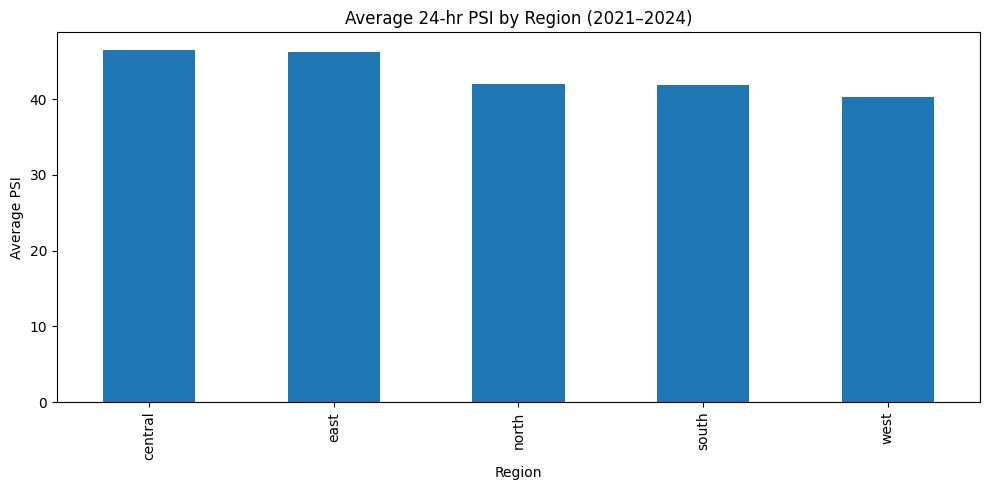

In [ ]:
psi[psi['region'] != 'national'].groupby('region')['psi_twenty_four_hourly'].mean().plot(
    kind='bar', figsize=(10,5),
    title='Average 24-hr PSI by Region (2021–2024)'
)
plt.xlabel('Region')
plt.ylabel('Average PSI')
plt.tight_layout()
plt.show()

The bar chart shows that Central and East consistently record the highest average 24-hour PSI (~46), while  West records are lowest roughly 40.The differences across regions are modest — roughly 6 PSI points separating the highest from the lowest but are consistent and meaningful for our analysis.

 This regional variation justifies our decision to use region-level PSI data rather than a single national average, as it allows us to capture environmental differences across HDB towns.

#### Step 7: Monthly trend of PM2.5 by region

While the regional averages above give a useful snapshot, they mask how air quality fluctuates over time. We therefore plot the monthly average PM2.5 by region across 2021–2024 to examine temporal trends and identify any notable spikes or seasonal patterns.

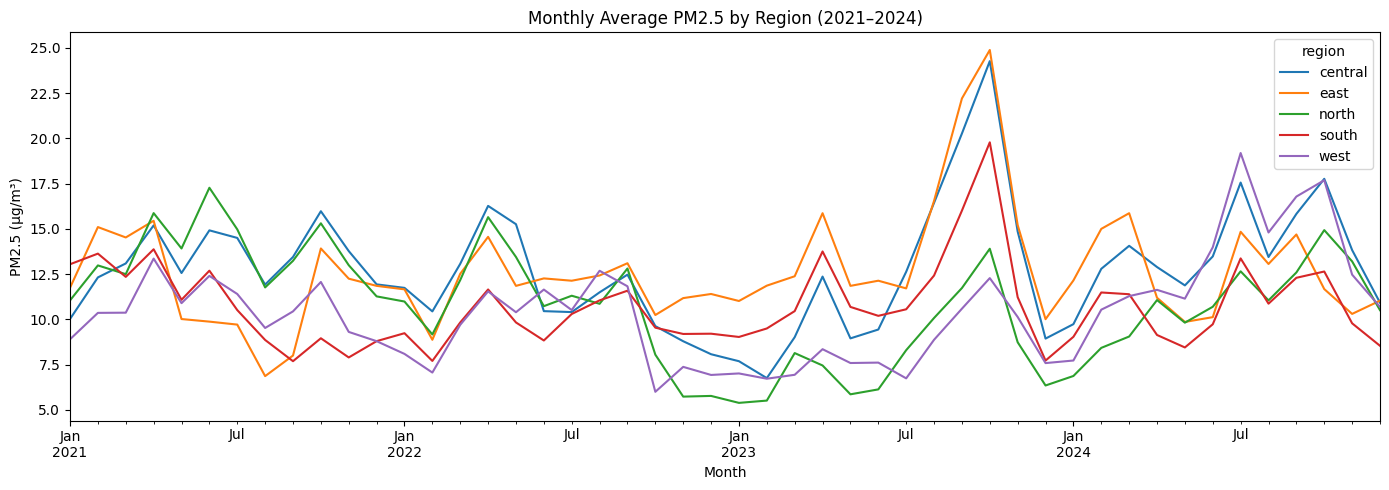

In [ ]:
psi['month'] = pd.to_datetime(psi['timestamp']).dt.to_period('M')

psi[psi['region'] != 'national'].groupby(
    ['month', 'region'])['pm25_twenty_four_hourly'].mean().unstack().plot(
    figsize=(14,5),
    title='Monthly Average PM2.5 by Region (2021–2024)'
)
plt.xlabel('Month')
plt.ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

The line chart reveals a clear spike in PM2.5 levels across all regions around mid-to-late 2023, reaching a peak of approximately 24–25 µg/m³ in the East and Central regions. This corresponds to the severe transboundary haze event in September 2023, caused by forest fires in Indonesia.



Beyond this spike, PM2.5 levels across regions generally track each other closely, with periodic seasonal fluctuations. The **East region consistently trends slightly higher than others across the full period**. This** temporal variation further reinforces the importance of using monthly aggregated PSI/PM2.5** values in our model rather than a static annual average.

#### Data Quality Assessment

**Positively assessed** — Completeness of core indicators: The two columns most critical to our analysis — pm25_twenty_four_hourly and psi_twenty_four_hourly — have a missing rate of approximately 5%, which is acceptably low. The available readings span all five regions consistently across four years, giving sufficient coverage for monthly aggregation. As the dataset is sourced from data.gov.sg, Singapore's official open data portal, it is expected to meet high standards of accuracy and reliability.

**Problematically assessed** — **Entirely empty column and excessive granularity:** The psi_three_hourly column is completely null across all 202,158 rows, rendering it unusable and requiring removal during data structuring. Additionally, co_eight_hour_max has approximately 41,087 missing values (~20%), significantly higher than other pollutant columns, suggesting inconsistent measurement coverage for carbon monoxide.

Beyond missing values, the dataset is recorded at hourly intervals which is far more granular than needed for our monthly-level analysis and **will require aggregation during data structuring** before it can be joined with the resale dataset.

#### Conclusion

The combined PSI dataset (DS2–DS5) is well-suited for our analysis, providing consistent region-level air quality readings across our target period of 2021–2024. Key points for subsequent steps:

**Data Structuring:**

* Convert date column from string to datetime format
* Aggregate hourly readings to monthly mean PM2.5 and PSI values per region
* Filter out national aggregate rows, retaining only the five regional readings
* Drop columns with no analytical value: psi_three_hourly (entirely null), region_id, timestamp, update_timestamp, location_longitude and location_latitude




**Data Enriching:**
* The cleaned monthly PSI table will be joined to the HDB resale dataset by matching region and year-month, tagging each resale transaction with the corresponding air quality reading for its region during that period

**Notable observation:**

* The significant PM2.5 spike in mid-2023 (transboundary haze event) is a notable feature that may have an outsized influence on model results and should be acknowledged during analysis

### DS6: Singapore Train Station Coordinates

**Description:**
This dataset was sourced from Kaggle and contains the coordinates of MRT and LRT stations across Singapore. It includes the station name, type (MRT/LRT), latitude and longitude. This directly addresses our requirement for MRT and LRT station locations, which we will use to compute the distance from each HDB town to its nearest train station as a proxy for accessibility.

#### Step 1: Load and preview the dataset

We first load the train station dataset and preview the first few rows to understand its structure and confirm that the data has been imported correctly. The dataset contains the station name, station type (MRT or LRT), and geographical coordinates (latitude and longitude) of train stations across Singapore.

In [ ]:
# Load dataset
mrt = pd.read_csv('/content/mrt_lrt_data.csv')

# Preview top 5 rows
mrt.head()

,station_name,type,lat,lng
0,Jurong East,MRT,1.333207,103.742308
1,Bukit Batok,MRT,1.349069,103.749596
2,Bukit Gombak,MRT,1.359043,103.751863
3,Choa Chu Kang,MRT,1.385417,103.744316
4,Yew Tee,MRT,1.397383,103.747523


Next, we examine the dataset structure to understand the number of rows, columns, and data types.

#### Step 2: Check shape and column info

In [ ]:
mrt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   station_name  157 non-null    object 
 1   type          157 non-null    object 
 2   lat           157 non-null    float64
 3   lng           157 non-null    float64
dtypes: float64(2), object(2)
memory usage: 5.0+ KB


The dataset contains 157 entries and 4 columns, including the station name, type, and geographic coordinates. The latitude and longitude columns are stored as float values, while station_name and type are categorical variables stored as object types.

This confirms that the dataset provides the required spatial information needed to calculate distances between HDB towns and nearby train stations. Next, we check for missing values to ensure data completeness.

#### Step 3: Check for missing values

In [ ]:
mrt.isnull().sum()

,0
station_name,0
type,0
lat,0
lng,0


The results show that all columns contain zero missing values, indicating that the dataset is complete. This ensures that the coordinates for all train stations are available for distance calculations without requiring additional data cleaning.

#### Step 4: Cardinalities — distinct values per column

In [ ]:
mrt.nunique()

,0
station_name,157
type,2
lat,155
lng,156


The dataset contains 157 unique station names, representing most of the MRT and LRT stations across Singapore. The type column contains two categories (MRT and LRT), confirming that the dataset includes both major rail systems.

The latitude and longitude columns contain a large number of unique values, which is expected for geographic coordinate data.

#### Step 5: Summary statistics

In [ ]:
mrt.describe()

,lat,lng
count,157.000000,157.000000
mean,1.345080,103.841362
std,0.044289,0.068544
min,1.265453,103.636866
25%,1.308474,103.790046
50%,1.337649,103.851550
75%,1.384116,103.893133
max,1.449133,103.988487




The summary statistics show that the latitude values range from approximately 1.265 to 1.449, while longitude values range from about 103.637 to 103.988. These ranges correspond to the geographical boundaries of Singapore.

This confirms that the coordinates accurately represent train station locations across the island and can be used to compute the distance between HDB towns and their nearest MRT or LRT stations

#### Step 6: Distribution of stations by type (MRT vs LRT)

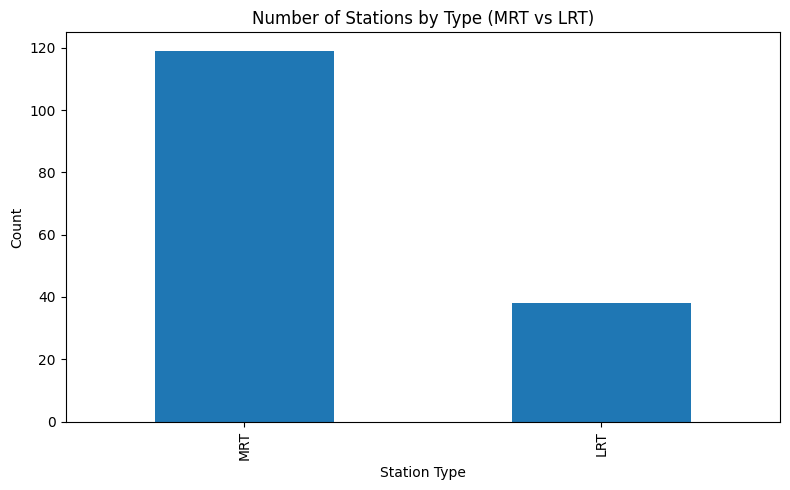

In [ ]:
mrt['type'].value_counts().plot(
    kind='bar', figsize=(8,5),
    title='Number of Stations by Type (MRT vs LRT)'
)
plt.xlabel('Station Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Step 7: Visualise station locations on a scatter plot

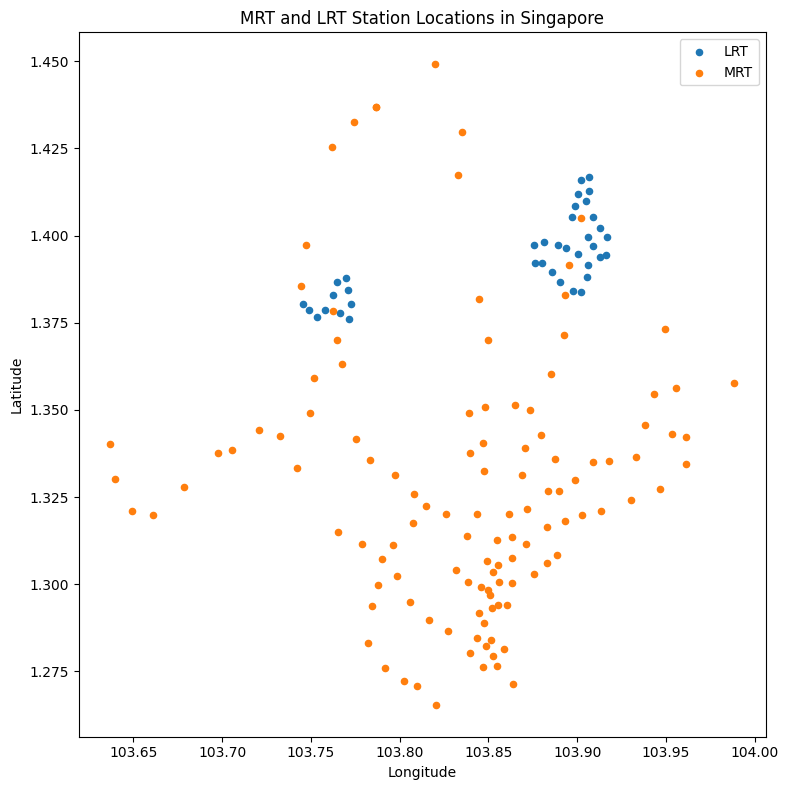

In [ ]:
plt.figure(figsize=(8,8))
for stype, group in mrt.groupby('type'):
    plt.scatter(group['lng'], group['lat'], label=stype, s=20)

plt.title('MRT and LRT Station Locations in Singapore')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()

To complement the type distribution above, we plot the geographical locations of all MRT and LRT stations across Singapore. The scatter plot confirms that MRT stations (orange) are spread across the entire island, while LRT stations (blue) are clustered in three distinct areas — the north-east (Sengkang and Punggol) and the west (Bukit Panjang)

The overall spread of stations across Singapore's geographic bounds gives us confidence that most HDB towns will have at least one station within a reasonable distance, making dist_to_nearest_mrt a meaningful and computable feature for our analysis.

#### Data Quality Assessment

**Positively assessed** — Completeness and coordinate accuracy: The dataset contains 157 entries with no missing values across all columns. Coordinate values fall entirely within Singapore's geographic bounds, making the dataset immediately usable for distance computation without any imputation or correction. As a widely used spatial reference for Singapore's train network, the dataset is reliable for transportation accessibility analysis.

**Problematically assessed** — Duplicate coordinates for interchange stations and non-official source: A small number of stations share identical or near-identical coordinates, corresponding to interchange stations that are physically co-located but listed as separate entries. If not handled carefully, this could result in double-counting during distance calculations. Additionally, as the dataset is sourced from Kaggle rather than an official government portal, there is a risk that the station list may not fully reflect the most current network — newer stations opened after the dataset's creation may be absent.

#### Conclusion

DS6 is highly suitable for our analysis with minimal preparation needed. Key points for subsequent steps:

**Data Structuring:**

Deduplicate stations with identical coordinates to avoid double-counting interchange stations


**Data Enriching:**

Coordinates will be used alongside DS9 town centroids to compute **dist_to_nearest_mrt** per town using the Haversine formula.
Both MRT and LRT stations will be treated equally as transit access points since both contribute to overall public transport accessibility

### DS7: Hospitals with Coordinates

**Description:**
This dataset was sourced from Kaggle and contains hospital names, addresses, postal codes, hospital type (public/private), latitude, longitude and town. This directly addresses our requirement for hospital locations, which we will use to compute the distance from each HDB town to its nearest hospital as a measure of healthcare accessibility.

#### Step 1: Load and preview

We first load the hospital dataset and preview the first few rows to understand its structure and confirm that the data has been imported correctly. The dataset contains information such as hospital name, address, postal code, hospital type (public/private), latitude, longitude, and town. Next, we examine the dataset structure to understand the number of rows, columns, and data types.

In [ ]:
hospitals = pd.read_csv('/content/hospitals_with_coordinates.csv')
hospitals.head()

,hospital_name,address,postal_code,hospital_type,latitude,longitude,town
0,Crawfurd Hospital,"19 Adam Road, Singapore 289891",289891,Private,1.326812,103.813328,Bukit Timah
1,Farrer Park Hospital,"1 Farrer Park Station Road, #02-01 Connexion, ...",217562,Private,1.312582,103.853915,Farrer Park
2,Gleneagles Hospital,"6A Napier Road, Singapore 258500",258500,Private,1.307378,103.819861,Tanglin
3,Mount Alvernia Hospital,"820 Thomson Road, Singapore 574623",574623,Private,1.341637,103.837264,Marymount
4,Mount Elizabeth Hospital,"3 Mount Elizabeth, Mount Elizabeth Hospital, S...",228510,Private,1.305255,103.835490,Orchard


#### Step 2: Shape and column info

In [ ]:
hospitals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hospital_name  24 non-null     object 
 1   address        24 non-null     object 
 2   postal_code    24 non-null     int64  
 3   hospital_type  24 non-null     object 
 4   latitude       24 non-null     float64
 5   longitude      24 non-null     float64
 6   town           24 non-null     object 
dtypes: float64(2), int64(1), object(4)
memory usage: 1.4+ KB


The dataset contains 24 entries and 7 columns. Geographic coordinates (latitude and longitude) are stored as float values, while hospital_name, address, hospital_type, and town are stored as object types. The postal_code column is stored as an integer.

This confirms that the dataset provides the spatial information needed to calculate the distance between HDB towns and nearby hospitals.

#### Step 3: Missing values

In [ ]:
hospitals.isnull().sum()

,0
hospital_name,0
address,0
postal_code,0
hospital_type,0
latitude,0
longitude,0
town,0


The results show that all columns contain zero missing values, indicating that the dataset is complete. This ensures that the hospital locations and coordinates are available for potential distance calculations.

#### Step 4: Cardinalities

In [ ]:
hospitals.nunique()

,0
hospital_name,24
address,23
postal_code,23
hospital_type,2
latitude,23
longitude,23
town,20


There are 24 unique hospital names but only 23 unique addresses, postal codes, latitude and longitude values, suggesting one pair of hospitals may share the same location — likely a hospital complex housing multiple institutions. There are only 2 hospital types (Public and Private) and 20 unique towns, meaning many HDB towns have no hospital within their boundaries at all. To better understand the type breakdown, we visualise the distribution of hospitals by type.

#### Step 5: Distribution by hospital type

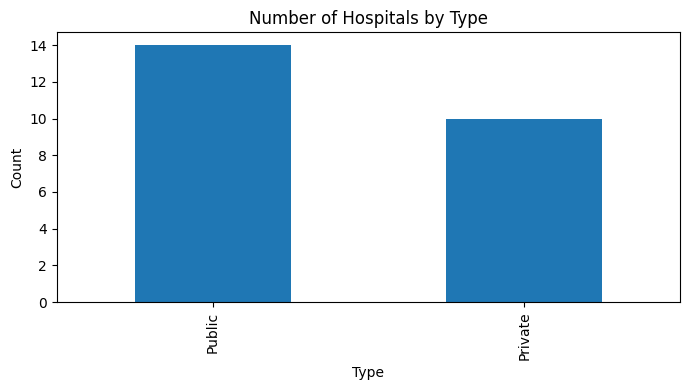

In [ ]:
hospitals['hospital_type'].value_counts().plot(
    kind='bar',
    figsize=(7,4),
    title='Number of Hospitals by Type'
)

plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The bar chart shows that there are 14 public hospitals and 10 private hospitals in Singapore. While public hospitals are more numerous, both types are geographically sparse  with only 24 hospitals across the entire island. To understand whether these hospitals are evenly spread or concentrated in certain areas, we plot their locations across Singapore.

#### Step 6: Hospital locations across Singapore

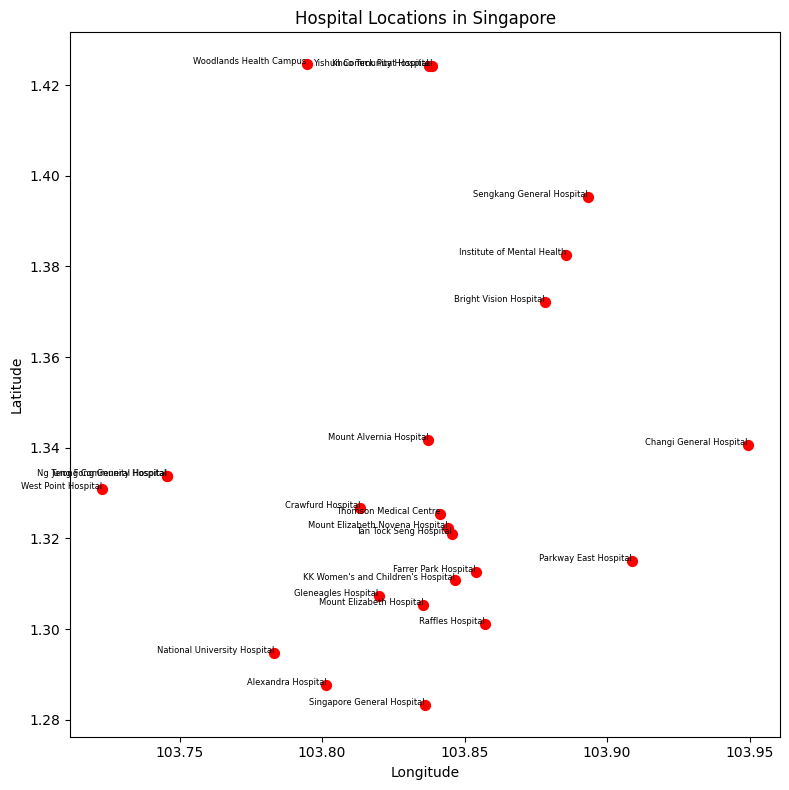

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(hospitals['longitude'], hospitals['latitude'], s=50, color='red')

for i, row in hospitals.iterrows():
    plt.annotate(row['hospital_name'], (row['longitude'], row['latitude']),
                 fontsize=6, ha='right')

plt.title('Hospital Locations in Singapore')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

The scatter plot reveals a critical limitation of this dataset  the vast majority of hospitals are clustered in the central region of Singapore, particularly around the Orchard, Novena and Bukit Timah areas. Only a handful of hospitals are located in the north (Woodlands, Yishun) and east (Changi, Sengkang), with very few in the west.

 This highly uneven geographic distribution means that most HDB towns, particularly in the west and north-east, would map to the same few hospitals when computing nearest-hospital distance, resulting in minimal variation in the *dist_to_nearest_hospital* feature across towns. These observations raise significant concerns about the suitability of this dataset for our analysis, which we now assess formally.

#### Data Quality Assessment

**Positively assessed** — Completeness and coordinate accuracy: The dataset is fully complete with no missing values across all 24 entries. Coordinate values fall within Singapore's geographic bounds and town assignments appear accurate, making it technically ready for distance computation without any cleaning required.

**Problematically assessed** — Insufficient size and geographic concentration: With only 24 hospitals in total, the dataset is far too small to generate a meaningful and discriminatory distance feature. The heavy geographic concentration of hospitals in the central region further compounds this issue.

The computed distance to nearest hospital would show very little variation across HDB towns, providing minimal explanatory power in our regression model compared to MRT stations (157 entries, island-wide) or schools (337 entries across all regions).

#### Conclusion


We disregard DS7 from further consideration after careful exploration. Despite being clean and complete, the dataset's small size of only 24 hospitals and their heavy concentration in central Singapore means that **dist_to_nearest_hospital** would exhibit very little variation across HDB towns. This severely limits its usefulness as an explanatory variable in our regression model, adding pipeline complexity without meaningful analytical benefit.

### DS8: General Information of Schools

**Description:**
This dataset was extracted from Singapore's open data portal, data.gov.sg, and contains general information on all schools in Singapore, including school name, address, postal code, zone, type, and nearest MRT station. This addresses our requirement for school locations across Singapore as a measure of education accessibility.

Unlike the hospital and MRT datasets, this dataset does not contain latitude and longitude coordinates. However, rather than geocoding postal codes using an external API which adds unnecessary complexity and potential errors. We will instead use the *dgp_code* column, which maps each school directly to its town (e.g. Woodlands, Yishun, Bishan).



 Since our resale price analysis operates at the town level, this approach is not only simpler but also more appropriate, as it allows us to directly **count the number of schools per town** as our accessibility measure. The zone_code column (North/South/East/West/Central) further allows us to cross-reference with our PSI regional data.


 All other irrelevant columns such as telephone, fax, URL and session code will be dropped during data structuring.

#### Step 1: Load and preview

We first load the schools dataset and preview the first few rows to understand its structure and confirm that the data has been imported correctly.

In [ ]:
schools = pd.read_csv('/content/General_Information_of_Schools.csv')
schools.head()

,school_name,url_address,address,postal_code,telephone_no,telephone_no_2,fax_no,fax_no_2,mrt_desc,bus_desc,...,nature_code,session_code,mainlevel_code,sap_ind,autonomous_ind,gifted_ind,ip_ind,mothertongue1_code,mothertongue2_code,mothertongue3_code
0,ADMIRALTY PRIMARY SCHOOL,https://admiraltypri.moe.edu.sg/,11 WOODLANDS CIRCLE,738907,63620598,na,63627512,na,Admiralty Station,"TIBS 965, 964, 913",...,CO-ED SCHOOL,FULL DAY,PRIMARY,No,No,No,No,CHINESE,MALAY,TAMIL
1,ADMIRALTY SECONDARY SCHOOL,http://www.admiraltysec.moe.edu.sg,31 WOODLANDS CRESCENT,737916,63651733,63654596,63652774,na,ADMIRALTY MRT,904,...,CO-ED SCHOOL,SINGLE SESSION,SECONDARY (S1-S5),No,No,No,No,CHINESE,MALAY,TAMIL
2,AHMAD IBRAHIM PRIMARY SCHOOL,http://www.ahmadibrahimpri.moe.edu.sg,10 YISHUN STREET 11,768643,67592906,na,67592927,na,Yishun,Yishun Ring Road - 812 (white plate); Yishun A...,...,CO-ED SCHOOL,SINGLE SESSION,PRIMARY,No,No,No,No,CHINESE,MALAY,TAMIL
3,AHMAD IBRAHIM SECONDARY SCHOOL,http://www.ahmadibrahimsec.moe.edu.sg,751 YISHUN AVENUE 7,768928,67585384,na,67557778,na,"CANBERRA MRT, YISHUN MRT","117, 167, 169, 800, 811, 812, 883, 856, 858, 8...",...,CO-ED SCHOOL,SINGLE SESSION,SECONDARY (S1-S5),No,No,No,No,CHINESE,MALAY,TAMIL
4,AI TONG SCHOOL,http://www.aitong.moe.edu.sg,100 Bright Hill Drive,579646,64547672,na,64532726,na,Bishan MRT,"410, 162, 52",...,CO-ED SCHOOL,SINGLE SESSION,PRIMARY,Yes,No,No,No,CHINESE,na,na


The dataset contains information such as school name, address, postal code, zone, type, and nearest MRT station, along with several administrative attributes.

#### Step 2: Shape and column info

In [ ]:
schools.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   school_name         337 non-null    object
 1   url_address         337 non-null    object
 2   address             337 non-null    object
 3   postal_code         337 non-null    int64 
 4   telephone_no        337 non-null    object
 5   telephone_no_2      337 non-null    object
 6   fax_no              337 non-null    object
 7   fax_no_2            337 non-null    object
 8   mrt_desc            337 non-null    object
 9   bus_desc            337 non-null    object
 10  dgp_code            337 non-null    object
 11  zone_code           337 non-null    object
 12  type_code           337 non-null    object
 13  nature_code         337 non-null    object
 14  session_code        337 non-null    object
 15  mainlevel_code      337 non-null    object
 16  sap_ind             337 no

The dataset contains 337 entries and 23 columns, with most variables stored as object types representing categorical or administrative information. The postal_code column is stored as an integer, while other fields such as dgp_code, zone_code, and type_code provide location and classification details for each school.

This confirms that the dataset provides sufficient information to identify school distribution across different towns and regions in Singapore.

#### Step 3: Missing values

In [ ]:
schools.isnull().sum()

,0
school_name,0
url_address,0
address,0
postal_code,0
telephone_no,0
telephone_no_2,0
fax_no,0
fax_no_2,0
mrt_desc,0
bus_desc,0


The results show that all columns contain zero missing values, indicating that the dataset is complete. This ensures that the school information can be used reliably for further analysis.

#### Step 4: Cardinalities

In [ ]:
schools.nunique()

,0
school_name,337
url_address,337
address,336
postal_code,335
telephone_no,335
telephone_no_2,18
fax_no,331
fax_no_2,6
mrt_desc,269
bus_desc,327


The dataset contains 337 unique schools across Singapore. The dgp_code column contains 28 unique towns, which aligns well with the town-level structure used in our resale housing dataset.

The zone_code column contains four regional categories (North, South, East, West), which allows the dataset to be linked with regional environmental data such as the PSI dataset. Other variables such as type_code and mainlevel_code classify schools by education level and category.

However, it is worth noting that several columns such as telephone_no_2 and fax_no_2 show only 18 and 6 unique values respectively in the cardinalities step, suggesting that "na" strings are used as placeholders rather than actual null values. Since these columns will be dropped entirely during structuring, this does not affect our analysis.To better understand the geographic spread of schools, we visualise the distribution by zone.

#### Step 5: Distribution of schools by zone

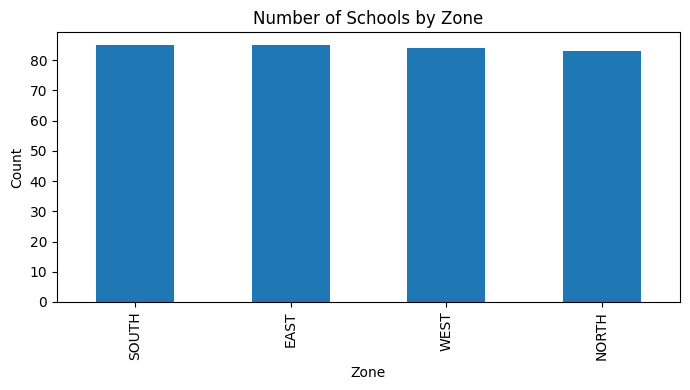

In [ ]:
schools['zone_code'].value_counts().plot(kind='bar', figsize=(7,4),
    title='Number of Schools by Zone')
plt.xlabel('Zone'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

The bar chart shows a remarkably even distribution of schools across all four zones South (roughly 85), East (roughly 85), West (roughly 83) and North (roughly 82)  with each zone hosting approximately the same number of schools. This is in stark contrast to the hospital dataset (DS7), where institutions were heavily concentrated in the central region

The even geographic spread of schools across Singapore gives us confidence that **number_of_schools_per_town** will show meaningful variation across HDB towns, making it a more discriminatory and analytically useful accessibility feature than hospital distance.

#### Step 6: Number of schools per town


To understand how school distribution varies at the town level, we plot the number of schools per town using the **dgp_code** column.

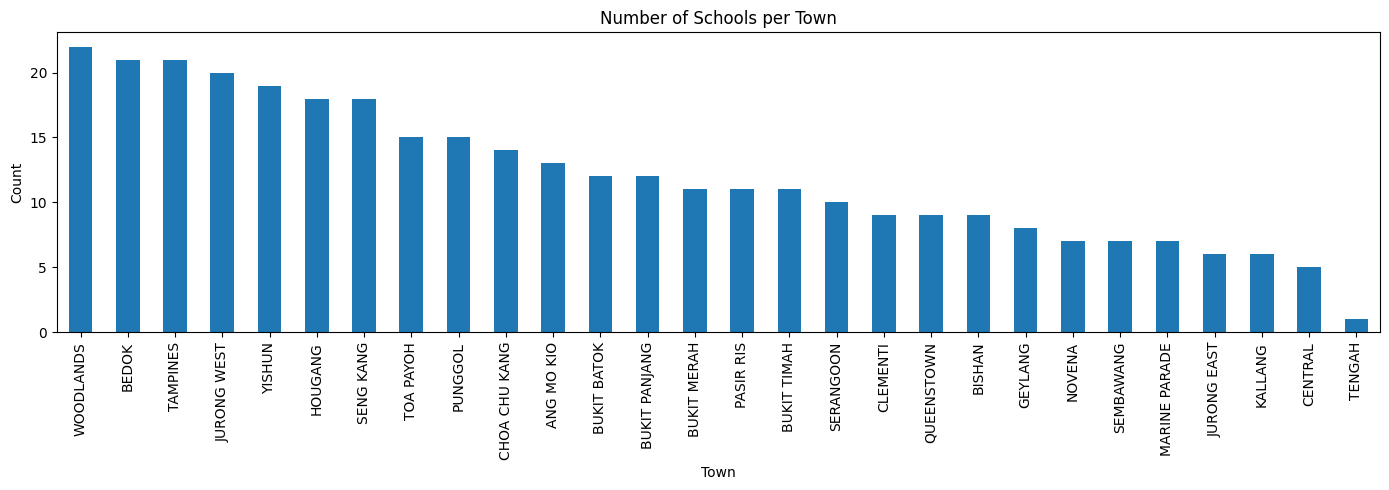

In [ ]:
schools['dgp_code'].value_counts().plot(
    kind='bar', figsize=(14,5),
    title='Number of Schools per Town'
)
plt.xlabel('Town')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The bar chart reveals clear variation across towns — Woodlands (22), Bedok (21) and Tampines (21) have the highest number of schools, while Tengah (1), Central (5) and Kallang (6) have the fewest. This meaningful variation across 28 towns confirms that school_count will serve as a useful and discriminatory accessibility feature in our regression model.

Larger towns with higher residential populations naturally tend to have more schools, which also aligns with our expectation that school accessibility may correlate with HDB resale prices in those areas

#### Data quality assessment

**Positively assessed** — Geographic coverage and even distribution: With 337 schools spread evenly across 28 towns and 4 zones, this dataset provides excellent geographic coverage for our town-level analysis. The even distribution ensures that the school_count feature will vary meaningfully across HDB towns, providing genuine explanatory power in our regression model. As the dataset is sourced from data.gov.sg, it meets high standards of accuracy and reliability.


**Problematically assessed** — Absence of coordinates and placeholder null values: The dataset does not contain latitude and longitude coordinates, unlike DS6 and DS7. While we work around this by using dgp_code for town-level aggregation, this means we cannot compute precise distance-to-nearest-school values and must rely on school count as a proxy instead. Additionally, missing values in columns like telephone_no_2 and fax_no_2 are represented as "na" strings rather than actual null values, meaning standard null-checking methods would not detect them

#### Conclusion

DS8 is well-suited for our analysis as a measure of education accessibility at the town level. Key points for subsequent steps:


**Data Structuring:**
* Drop irrelevant columns: **url_address, telephone_no, telephone_no_2, fax_no, fax_no_2, bus_desc, session_code, sap_ind, autonomous_ind, gifted_ind, ip_ind, mothertongue1_code, mothertongue2_code, mothertongue3_code**
* Retain key columns: **school_name, dgp_code, zone_code, mainlevel_code**
* Group by dgp_code to count the number of schools per town, generating a school_count feature

**Data Enriching:**
* The school_count per town will be joined to the HDB resale dataset by matching on town, adding education accessibility as an explanatory variable in our regression model


### DS9: Singapore City Geo-Coordinates

**Description:**
This dataset was sourced from Kaggle and contains the latitude and longitude of towns and cities across Singapore, along with their corresponding region (North, South, East, West, Central). This dataset serves as a critical geographic mapping table in our analysis as it allows us to map each HDB town to its coordinates and region, which is essential for linking the resale price data with the PSI air quality data (which is region-based) and for computing distances to amenities.

#### Step 1: Load and preview

We first load the Singapore city geo-coordinates dataset and preview the first few rows to understand its structure and confirm that the data has been imported correctly. The dataset contains information such as place name, city (town), region (area), and geographic coordinates (latitude and longitude).

In [ ]:
sg_coords = pd.read_csv('/content/singapore_city_coordinates_improved.csv')
sg_coords.head()

,Place,City,Area,latitude,longitude,bounding_box_1,bounding_box_2,bounding_box_3,bounding_box_4
0,Bishan East,Bishan,central,1.351912,103.848971,1.341685,1.367983,103.818451,103.860476
1,Marymount,Bishan,central,1.348604,103.839393,1.347739,1.349522,103.838921,103.840169
2,Upper Thomson,Bishan,central,1.354639,103.832512,1.353404,1.355813,103.831599,103.834056
3,Alexandra Hill,Bukit Merah,central,1.277477,103.801880,1.257477,1.297477,103.781880,103.821880
4,Alexandra North,Bukit Merah,central,1.277477,103.801880,1.257477,1.297477,103.781880,103.821880


#### Step 2: Shape and column info

In [ ]:
sg_coords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Place           332 non-null    object 
 1   City            332 non-null    object 
 2   Area            332 non-null    object 
 3   latitude        315 non-null    float64
 4   longitude       315 non-null    float64
 5   bounding_box_1  315 non-null    float64
 6   bounding_box_2  315 non-null    float64
 7   bounding_box_3  315 non-null    float64
 8   bounding_box_4  315 non-null    float64
dtypes: float64(6), object(3)
memory usage: 23.5+ KB


The dataset contains 332 entries and 9 columns. Geographic coordinates such as latitude and longitude are stored as float values, while variables such as Place, City, and Area are stored as object types representing locations and regions in Singapore.

Additional columns such as bounding_box_1 to bounding_box_4 represent geographic boundary information for each location. However, these bounding box variables are not required for our analysis and will be removed during data structuring.





#### Step 3: Missing values

In [ ]:
sg_coords.isnull().sum()

,0
Place,0
City,0
Area,0
latitude,17
longitude,17
bounding_box_1,17
bounding_box_2,17
bounding_box_3,17
bounding_box_4,17


The dataset contains 17 missing values in the coordinate-related columns, including latitude, longitude, and the bounding box variables. Since our analysis requires only the main coordinates for mapping towns, we will retain rows with valid latitude and longitude values and drop unnecessary columns during cleaning

#### Step 4: Cardinalities

In [ ]:
sg_coords.nunique()

,0
Place,331
City,55
Area,5
latitude,286
longitude,286
bounding_box_1,285
bounding_box_2,286
bounding_box_3,286
bounding_box_4,286


There are 331 unique Place values out of 332 rows, suggesting one duplicate place name exists. More importantly, the City column has 55 distinct values — representing the broader towns across Singapore and Area has only 5 distinct values (North, South, East, West, Central), which aligns with our PSI regional breakdown.



The 286 unique coordinate pairs compared to 332 rows confirms that multiple sub-areas within the same town share the same or similar coordinates, which is expected given the granularity of the dataset. To verify whether DS9 covers all HDB towns present in our resale dataset, we perform a cross-check.

#### Step 5: Check all HDB towns are covered

In [ ]:
# Check which resale towns are missing from sg_coords
resale_towns = set(resale['town'].unique())
coord_towns = set(sg_coords['City'].str.upper().unique())
missing = resale_towns - coord_towns
print(f"Towns in resale not found in DS9: {missing}")

Towns in resale not found in DS9: {'CENTRAL AREA', 'KALLANG/WHAMPOA'}


The cross-check reveals that two towns in the resale dataset are **not found in DS9: KALLANG/WHAMPOA and CENTRAL AREA.** This is a notable data quality issue — these two towns appear in DS1 but cannot be mapped to coordinates using DS9 as-is, which would cause them to be excluded from distance calculations during data enrichment.


During data structuring, we will manually add entries for these two towns with their known approximate coordinates to ensure full coverage of all HDB towns.


#### Step 6: Visualise all town coordinates on a scatter plot


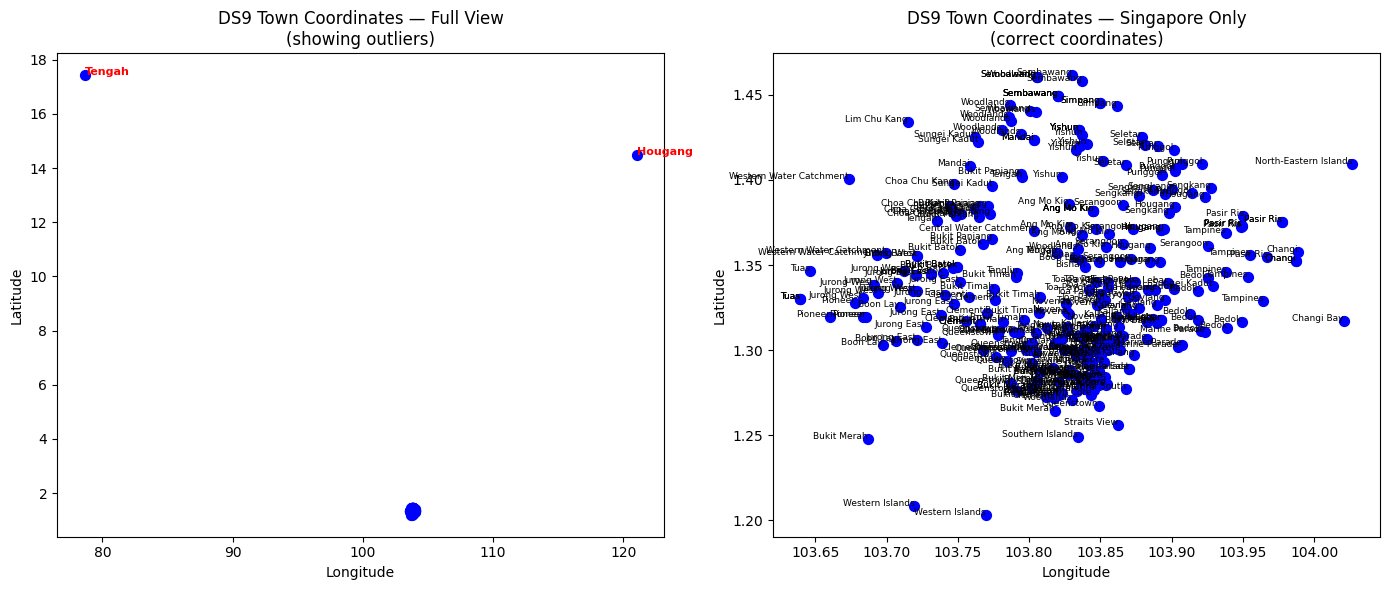

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Full view showing outliers
axes[0].scatter(sg_coords['longitude'], sg_coords['latitude'], s=50, color='blue')
axes[0].set_title('DS9 Town Coordinates — Full View\n(showing outliers)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
for i, row in sg_coords.iterrows():
    if abs(row['latitude'] - 1.352) > 1 or abs(row['longitude'] - 103.82) > 1:
        axes[0].annotate(row['City'], (row['longitude'], row['latitude']),
                         fontsize=8, color='red', fontweight='bold')

# Plot 2: Zoomed in to Singapore only (correct towns)
sg_only = sg_coords[
    (abs(sg_coords['latitude'] - 1.352) <= 1) &
    (abs(sg_coords['longitude'] - 103.82) <= 1)
]
axes[1].scatter(sg_only['longitude'], sg_only['latitude'], s=50, color='blue')
axes[1].set_title('DS9 Town Coordinates — Singapore Only\n(correct coordinates)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
for i, row in sg_only.iterrows():
    axes[1].annotate(row['City'], (row['longitude'], row['latitude']),
                     fontsize=6.5, ha='right')

plt.tight_layout()
plt.show()

#### Step 7: Identify problematic rows with wrong coordinates

In [ ]:
# Singapore reference coordinate
sg_lat = 1.352083
sg_lon = 103.819836

# rows that are likely problematic (far from Singapore center)
bad_rows = sg_coords[
    (abs(sg_coords['latitude'] - sg_lat) > 1) |
    (abs(sg_coords['longitude'] - sg_lon) > 1)
]

print(bad_rows)

         Place     City        Area   latitude   longitude  bounding_box_1  \
269       Park   Tengah        west  17.428784   78.642148       17.428451   
305  Trafalgar  Hougang  north-east  14.485000  121.022243       14.484983   

     bounding_box_2  bounding_box_3  bounding_box_4  
269       17.429116       78.641945       78.642349  
305       14.485000      121.022243      121.022345  


Inspecting the rows with suspicious coordinates reveals two problematic entries — Tengah (lat: 17.43, lng: 78.64) and Hougang (lat: 14.49, lng: 121.02), which correspond to locations in Hyderabad, India and Manila, Philippines respectively. These are clearly erroneous values, likely introduced during dataset creation. Both will be corrected with their actual Singapore coordinates during data structuring before any distance computation is performed.

#### Data Quality assessment

**Positively assessed** — Regional mapping and broad town coverage: The Area column provides clean and consistent region labels (North, South, East, West, Central) across all 332 entries with no missing values, making it immediately usable for linking HDB towns to their corresponding PSI region. With 55 distinct towns covered, the dataset provides broad geographic coverage across Singapore, serving as the critical geographic backbone connecting all other datasets.


**Problematically assessed** — Erroneous coordinates and incomplete town coverage: Two rows contain clearly incorrect coordinates — Tengah and Hougang point to locations in Hyderabad, India and Manila, Philippines respectively, rendering them unusable for distance computation as-is. Additionally, 17 rows have missing latitude and longitude values entirely, and two HDB towns (KALLANG/WHAMPOA and CENTRAL AREA) are absent from DS9 altogether. All three issues must be resolved during data structuring to ensure accurate distance calculations and full town coverage.

#### Conclusion


DS9 is essential to our analysis as the geographic backbone that connects all other datasets. Despite the coordinate issues identified, they are resolvable during data structuring. Key points for subsequent steps:

**Data Structuring:**
* Correct erroneous coordinates for Tengah and Hougang with their actual Singapore coordinates
* Drop rows with missing latitude and longitude values
* Drop bounding box columns as they are not needed
* Manually add entries for KALLANG/WHAMPOA and CENTRAL AREA with their known approximate coordinates
* Group by City and compute mean latitude and longitude per town to obtain a single centroid coordinate per town

**Data Enriching:**

* Town centroid coordinates will be used alongside DS6 to compute dist_to_nearest_mrt per town using the Haversine formula
* The Area column will be used to map each HDB town to its corresponding PSI region from DS2–DS5, linking air quality data to resale transactions
* School count per town from DS8 will be joined by town name to add education accessibility as an explanatory variable





## **Data Preparation - Data Structuring (Process)**

###Overview

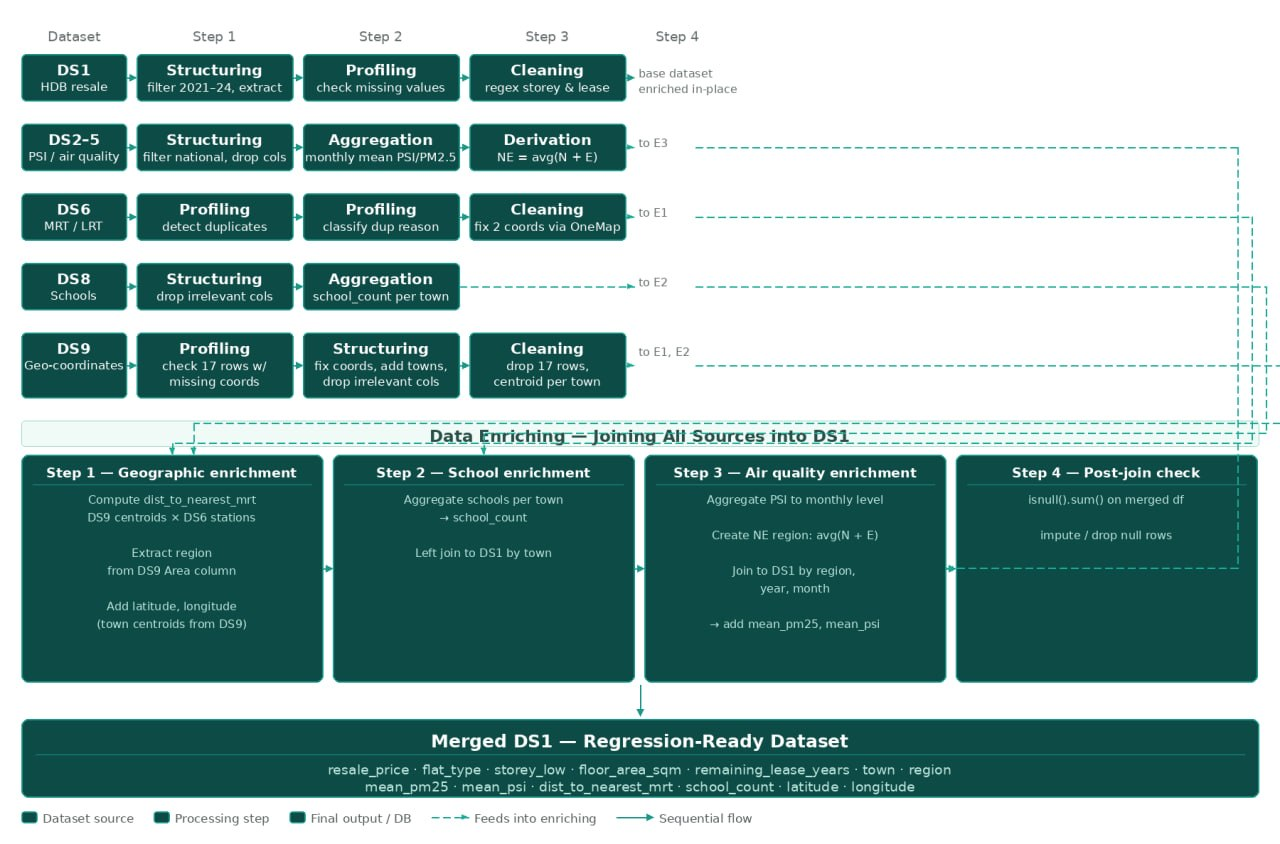

As part of data preparation, we implemented the transformation and profiling steps summarised in the diagram above.

DS1, containing HDB resale flat transaction records, is structured by filtering to 2021–2024, extracting numeric values from string-encoded columns, and converting date formats. It is then profiled for completeness and cleaned using regex extraction.

DS2–DS5, containing hourly PSI readings across Singapore's regions, are structured by filtering out national aggregate rows and dropping irrelevant columns. Readings are aggregated to monthly mean PSI and PM2.5 values per region. A derivation step synthesises a North-East PSI value by averaging the North and East readings, ensuring full regional coverage.

DS6, containing MRT and LRT station coordinates, is profiled to detect and check the reason for duplicate coordinates, either from interchange stations or error in coordinate data, which are then removed or fix.

DS8, containing school information, is structured by dropping irrelevant columns and aggregated by town to produce a school_count feature.

DS9, containing town-level coordinates, is cleaned to correct erroneous entries and add two missing HDB towns, then structured to derive a single centroid coordinate per town.

These processed datasets are then combined through four enriching steps — computing MRT distances via the Haversine formula, joining regional PSI readings, adding school counts, and performing a final post-join check to resolve any nulls introduced by the joins.

The resulting regression-ready dataset, combining resale transaction records with air quality indicators, transit accessibility, and school accessibility, forms the basis for our subsequent analysis.

###Structuring data from DS1

**Conversion of the 'month' column**

Currently, in the month column, the data is stored as string in this format : "YYYY-MM", which cannot be used numerically. We convert it to datetime first, then extract year and month_num as integer columns so they can serve as meaningful features in regression.

In [ ]:
# Convert 'month' from string to datetime, then extract year and month as separate columns
# This allows us to filter by year and use month as a numeric feature in regression
resale['month'] = pd.to_datetime(resale['month'], format='%Y-%m')
resale['year'] = resale['month'].dt.year
resale['month_num'] = resale['month'].dt.month

resale[['month', 'year', 'month_num']].head()

,month,year,month_num
0,2017-01-01,2017,1
1,2017-01-01,2017,1
2,2017-01-01,2017,1
3,2017-01-01,2017,1
4,2017-01-01,2017,1


**Filtering rows**

 The dataset spans from 2017 onwards, but our analysis focuses on recent trends (2021–2024), which also aligns with our DS2. Dropping earlier records reduces noise from pre-pandemic market conditions and keeps the data relevant. reset_index ensures the index is clean after filtering.

In [ ]:
# Keep only transactions from 2021 to 2024, dropping earlier records
resale = resale[resale['year'].between(2021, 2024)].reset_index(drop=True)

# Verify only the expected years remain
resale['year'].unique()

array([2021, 2022, 2023, 2024], dtype=int32)

**Extraction**

 storey_range is a string that cannot be used in regression. We extract storey_low as a numeric proxy for floor level, since higher floors generally correlate with higher resale prices. The lower bound is used as a conservative and consistent representation.

In [ ]:
# Extract the lower bound of the storey range as an integer
# e.g. "10 TO 12" → 10
resale['storey_low'] = resale['storey_range'].str.split(' TO ').str[0].astype(int)

# Verify
resale[['storey_range', 'storey_low']].head()

,storey_range,storey_low
0,01 TO 03,1
1,07 TO 09,7
2,04 TO 06,4
3,04 TO 06,4
4,01 TO 03,1


We will be doing the same to remaining_leasing as it was stored similarly as storey_range. We extract only the year component and discard the months portion, as the difference of a few months has negligible impact on resale price compared to the year-level lease duration.

In [ ]:
# Extract the number of remaining lease years as an integer
# e.g. "61 years 04 months" → 61
resale['remaining_lease_years'] = resale['remaining_lease'].str.extract(r'(\d+)\s+year').astype(int)

# Verify
resale[['remaining_lease', 'remaining_lease_years']].head()

,remaining_lease,remaining_lease_years
0,64 years 01 month,64
1,64 years 01 month,64
2,59 years,59
3,58 years 02 months,58
4,58 years 01 month,58


**Dropping irrelevant columns**

The reason for dropping each column are as follow:


1.   month: It has been replaced by year and month_num, hence we do not need to repeat the information again

2.   block and street_name: Too granular, not useful as a regression feature. Additionally, since we are relateding the data with the air quality which is based on region and area, such information will not be useful

3. flat_model: Redundant with flat_type for regression purposes

4. remaining_lease: Replace by remaining_lease_years

5. storey_range: Replaced by storey_low



In [ ]:
# Drop columns that are no longer needed after extraction or are irrelevant to regression
resale = resale.drop(columns=[
    'month',
    'block',
    'street_name',
    'flat_model',
    'remaining_lease',
    'storey_range'
])

resale.head()

,town,flat_type,floor_area_sqm,lease_commence_date,resale_price,storey_low,remaining_lease_years,year,month_num
0,ANG MO KIO,2 ROOM,45.0,1986,211000.0,1,64,2021,1
1,ANG MO KIO,2 ROOM,45.0,1986,225000.0,7,64,2021,1
2,ANG MO KIO,3 ROOM,68.0,1981,260000.0,4,59,2021,1
3,ANG MO KIO,3 ROOM,68.0,1980,265000.0,4,58,2021,1
4,ANG MO KIO,3 ROOM,68.0,1980,265000.0,1,58,2021,1


###Structuring data from DS2-5

**Conversion from string to datetime and Extraction of month and year**

Similar to DS1, the date of DS2 is in the string , hence we will need to convert to datetime. However, different from previously, the format in which the date is stored differs for these 4 datasets. DS2,3 and 5 stored as "DD/MM/YYYY", whereas DS4 is stored as "YYYY-MM-DD".

In [ ]:
# Convert 'date' from string to datetime
# format='mixed' is needed because date formats are inconsistent across the four CSV files
# dayfirst=True handles the DD/MM/YYYY cases correctly
psi['date'] = pd.to_datetime(psi['date'], format='mixed', dayfirst=True)
psi['year'] = psi['date'].dt.year
psi['month_num'] = psi['date'].dt.month

psi[['date', 'year', 'month_num']].head()

,date,year,month_num
0,2021-01-01,2021,1
1,2021-01-01,2021,1
2,2021-01-01,2021,1
3,2021-01-01,2021,1
4,2021-01-01,2021,1


**Filter row**

The national entry is an aggregated summary across all regions and would duplicate information already captured by the individual region rows. Keeping it would inflate the data and skew the monthly aggregation later. We retain only the five regional entries (north, south, east, west, central).

In [ ]:
# Remove rows where region is 'national' — we want region-level data only
psi = psi[psi['region'] != 'national'].reset_index(drop=True)

# Verify 'national' no longer exists
psi['region'].unique()

array(['south', 'north', 'east', 'central', 'west'], dtype=object)

**Dropping irrelavent columns**

The dropped columns fall into a few categories:
1. sub-index components (e.g. pm10_sub_index, o3_sub_index) are intermediate calculations not directly meaningful for our analysis

2. geographic coordinates (location_longitude, location_latitude) are redundant since region already captures location

3. timestamp columns (timestamp, update_timestamp) are administrative metadata irrelevant to regression.

We retain only pm25_twenty_four_hourly and psi_twenty_four_hourly as they are the most direct air quality indicators relevant to housing.

In [ ]:
# Retain only the columns needed for analysis
psi = psi[['date', 'region', 'year', 'month_num', 'pm25_twenty_four_hourly', 'psi_twenty_four_hourly']]

psi.head()

,date,region,year,month_num,pm25_twenty_four_hourly,psi_twenty_four_hourly
0,2021-01-01,south,2021,1,16.0,55.0
1,2021-01-01,north,2021,1,13.0,52.0
2,2021-01-01,east,2021,1,16.0,55.0
3,2021-01-01,central,2021,1,12.0,50.0
4,2021-01-01,west,2021,1,9.0,37.0


**Aggregate to monthly level by region**

The raw PSI data is recorded at a sub-daily or daily frequency, which is far more granular than the resale dataset which is at a monthly level. Aggregating to monthly means per region allows us to later merge cleanly with the resale data on year and month_num. Taking the mean smooths out short-term fluctuations and gives a representative air quality reading for each region per month.

In [ ]:
# Group by region, year and month → compute mean PSI and PM2.5 for each region per month
psi_monthly = (
    psi
    .groupby(['region', 'year', 'month_num'], as_index=False)
    .agg(
        mean_pm25=('pm25_twenty_four_hourly', 'mean'),
        mean_psi=('psi_twenty_four_hourly', 'mean')
    )
)

psi_monthly.head()

,region,year,month_num,mean_pm25,mean_psi
0,central,2021,1,10.025157,39.790881
1,central,2021,2,12.321364,46.692998
2,central,2021,3,13.093023,48.775650
3,central,2021,4,15.194524,52.567723
4,central,2021,5,12.564315,47.470263


**Create North-East PSI rows by averaging North and East regions**

The resale dataset classifies HDB towns into six regions — North, South, East, West, Central, and North-East — following HDB's official regional classification. However, NEA's PSI monitoring data only covers five regions: North, South, East, West, and Central. The North-East region has no direct PSI equivalent, which would result in NaN values for all North-East towns during the enrichment join if left unaddressed. This is therefore needed to be resolved to ensure the PSI table is complete and fully compatible before any joining takes place.

To derive representative PSI and PM2.5 values for the North-East region, we compute the monthly average of the North and East regional readings. This approach is grounded in geography — the North-East region of Singapore sits between the North and East PSI monitoring zones, making the average of the two the most logical and neutral approximation of air quality conditions in that area.

This is further supported by Singapore's small geographic size, which means air quality readings across adjacent regions tend to be similar with minimal variance. The difference between North and East PSI readings in any given month is therefore unlikely to be large, making their average a reliable proxy for North-East conditions. This approach is also internally consistent — every North-East month is derived using the same method with no subjective per-town decisions, unlike an alternative approach of individually mapping each North-East town to either the North or East zone, which would require arbitrary boundary decisions in the absence of officially defined NEA monitoring boundaries.

The resulting psi_monthly table now covers all six HDB regions, ensuring a complete join with the resale dataset during enrichment with no missing PSI values for North-East towns.

In [ ]:
# Extract North and East monthly PSI data
psi_north = psi_monthly[psi_monthly['region'] == 'north'].set_index(['year', 'month_num'])
psi_east = psi_monthly[psi_monthly['region'] == 'east'].set_index(['year', 'month_num'])

# Compute average of North and East for each month
psi_northeast = ((psi_north[['mean_pm25', 'mean_psi']] + psi_east[['mean_pm25', 'mean_psi']]) / 2).reset_index()
psi_northeast['region'] = 'north-east'

# Append to psi_monthly
print(f"Rows before: {psi_monthly.shape[0]}")
psi_monthly = pd.concat([psi_monthly, psi_northeast], ignore_index=True)
print(f"Rows after:  {psi_monthly.shape[0]}")

# Verify
psi_monthly[psi_monthly['region'] == 'north-east'].head()

Rows before: 240
Rows after:  288


,region,year,month_num,mean_pm25,mean_psi
240,north-east,2021,1,11.400943,43.922170
241,north-east,2021,2,14.043088,51.714542
242,north-east,2021,3,13.514364,49.706566
243,north-east,2021,4,15.661383,53.654899
244,north-east,2021,5,11.970954,45.391425


###Structuring data from DS6

**Remove potential duplicates**

During profiling, we noted that some MRT stations are interchange. For example, Dhoby Ghuat has 3 lines (North–South (NSL), North East (NEL) and Circle (CCL) lines). Since this dataset is used purely for distance computation, duplicate coordinates would cause the same physical location to be counted multiple times and skew proximity calculations.

However, we would have to verify if there are any duplicates first. This is done by checking for the station_names and the coordinates.

In [ ]:
# Check for duplicate station names (same name, different coordinates)
dup_names = mrt[mrt.duplicated(subset=['station_name'], keep=False)]
print(f"Same station name, potentially different coordinates: {dup_names.shape[0]} rows")
if dup_names.shape[0] > 0:
    print(dup_names.sort_values('station_name')[['station_name', 'lat', 'lng']])

print()

# Check for duplicate coordinates (same coordinates, different station names)
dup_coords = mrt[mrt.duplicated(subset=['lat', 'lng'], keep=False)]
print(f"Same coordinates, potentially different station names: {dup_coords.shape[0]} rows")
if dup_coords.shape[0] > 0:
    print(dup_coords.sort_values(['lat', 'lng'])[['station_name', 'lat', 'lng']])

Same station name, potentially different coordinates: 0 rows

Same coordinates, potentially different station names: 2 rows
  station_name       lat         lng
7    Woodlands  1.436984  103.786406
8    Admiralty  1.436984  103.786406


The duplicate coordinate check revealed that Woodlands and Admiralty MRT stations share identical coordinates in the source dataset, which is clearly erroneous as they are two distinct stations located approximately 1.5km apart on the NSL. Rather than dropping one of the stations — which would incorrectly remove a real station from the distance computation — the coordinates were corrected using the OneMap API (Singapore Land Authority), consistent with the approach used for coordinate corrections elsewhere in this project. The verification output confirms that both stations now have distinct and correct coordinates.

In [ ]:
# Helper function to fetch coordinates from OneMap API (SLA)
# Reused throughout the structuring section for transparent coordinate sourcing
def get_onemap_coords(search_term, fallback_lat, fallback_lng):
    try:
        url = f"https://www.onemap.gov.sg/api/common/elastic/search?searchVal={search_term}&returnGeom=Y&getAddrDetails=Y&pageNum=1"
        response = requests.get(url)
        results = response.json().get('results', [])
        if len(results) == 0:
            print(f"No results found for '{search_term}', using fallback coordinates.")
            return fallback_lat, fallback_lng
        result = results[0]
        print(f"Found '{search_term}': {result['SEARCHVAL']}")
        return round(float(result['LATITUDE']), 6), round(float(result['LONGITUDE']), 6)
    except Exception as e:
        print(f"Error fetching '{search_term}': {e}, using fallback coordinates.")
        return fallback_lat, fallback_lng

# Fix incorrect coordinates for Woodlands and Admiralty using OneMap
woodlands_lat, woodlands_lng = get_onemap_coords("Woodlands MRT Station", fallback_lat=1.436900, fallback_lng=103.786400)
admiralty_lat, admiralty_lng = get_onemap_coords("Admiralty MRT Station", fallback_lat=1.440700, fallback_lng=103.800900)

print(f"Woodlands MRT → lat: {woodlands_lat}, lng: {woodlands_lng}")
print(f"Admiralty MRT → lat: {admiralty_lat}, lng: {admiralty_lng}")

# Apply the corrected coordinates
mrt.loc[mrt['station_name'].str.upper() == 'WOODLANDS', ['lat', 'lng']] = [woodlands_lat, woodlands_lng]
mrt.loc[mrt['station_name'].str.upper() == 'ADMIRALTY', ['lat', 'lng']] = [admiralty_lat, admiralty_lng]

# Verify the fix — should now show different coordinates
mrt[mrt['station_name'].str.upper().isin(['WOODLANDS', 'ADMIRALTY'])][['station_name', 'lat', 'lng']]

Found 'Woodlands MRT Station': WOODLANDS MRT STATION (NS9)
Found 'Admiralty MRT Station': ADMIRALTY MRT STATION (NS10)
Woodlands MRT → lat: 1.43682, lng: 103.786067
Admiralty MRT → lat: 1.440589, lng: 103.800991


,station_name,lat,lng
7,Woodlands,1.436820,103.786067
8,Admiralty,1.440589,103.800991


###Structuring data from DS8

**Dropping irrelevant columns**

The dropped columns fall into several categories:
1. Administrative metadata such as contact details (telephone_no, fax_no, url_address) and transport information (bus_desc, mrt_desc) which are irrelevant to our analysis.

2. Programme indicators (sap_ind, autonomous_ind, gifted_ind, ip_ind) and mother tongue codes are too granular for our purposes.

3. Address fields (address, postal_code) are redundant since we will be working at the town level using dgp_code.

We retain only school_name, dgp_code, zone_code, and mainlevel_code as these are sufficient for aggregating school counts by town.

In [ ]:
# Retain only columns relevant to the analysis
schools = schools[['school_name', 'dgp_code', 'zone_code', 'mainlevel_code']]

schools.head()

,school_name,dgp_code,zone_code,mainlevel_code
0,ADMIRALTY PRIMARY SCHOOL,WOODLANDS,NORTH,PRIMARY
1,ADMIRALTY SECONDARY SCHOOL,WOODLANDS,NORTH,SECONDARY (S1-S5)
2,AHMAD IBRAHIM PRIMARY SCHOOL,YISHUN,NORTH,PRIMARY
3,AHMAD IBRAHIM SECONDARY SCHOOL,YISHUN,NORTH,SECONDARY (S1-S5)
4,AI TONG SCHOOL,BISHAN,SOUTH,PRIMARY


**Aggregating school count by town**

For regression purposes, what matters is not individual school details but rather how many schools are accessible within a given town. Aggregating by dgp_code (which represents the town/planning area) gives us a single school_count value per town, which can then be merged with the resale dataset on dgp_code as a proxy for educational amenity accessibility.

In [ ]:
# Count number of schools per town
schools_agg = (
    schools
    .groupby('dgp_code', as_index=False)
    .agg(school_count=('school_name', 'count'))
)

schools_agg.head()

,dgp_code,school_count
0,ANG MO KIO,13
1,BEDOK,21
2,BISHAN,9
3,BUKIT BATOK,12
4,BUKIT MERAH,11


###Structuring data from DS9

**Drop rows with missing latitude and/or longitude**

Before dropping any rows with missing coordinates, we first surface and assess them to determine whether their removal would result in any meaningful loss of data. Simply dropping missing values without investigation risks discarding rows that correspond to legitimate residential areas, which would introduce gaps in the dataset and affect the accuracy of downstream computations.

Upon inspection, all 17 affected subzones were assessed individually against their land use classification. The majority are clearly non-residential comprising

1.  industrial estates and parks (Pasir Ris Wafer Fab Park, Tengah Industrial Estate, Tuas Promenade, Tuas View Extension, Gul Basin, Serangoon North Industrial Estate)

2. military and government land (PLAB Paya Lebar, Istana Negara)

3. offshore and island areas (Southern Group, Southern Islands, Jurong Island and Bukom, Western Islands, Tanjong Irau)

4. CBD/commercial subzones (Bayfront Subzone, Central Subzone)



In [ ]:
# Identify rows with missing coordinates
missing_coords = sg_coords[sg_coords['latitude'].isna() | sg_coords['longitude'].isna()]
print(f"Rows with missing coordinates: {missing_coords.shape[0]}")
missing_coords[['Place', 'City', 'latitude', 'longitude']]

Rows with missing coordinates: 17


,Place,City,latitude,longitude
29,Bayfront Subzone,Downtown Core,NaN,NaN
32,Central Subzone,Downtown Core,NaN,NaN
67,Istana Negara,Newton,NaN,NaN
117,Southern Group,Southern Islands,NaN,NaN
152,Tanjong Irau,Simpang,NaN,NaN
194,Pasir Ris Wafer Fab Park,Pasir Ris,NaN,NaN
200,PLAB,Paya Lebar,NaN,NaN
229,Peng Siang,Choa Chu Kang,NaN,NaN
246,Lakeside (Leisure),Jurong East,NaN,NaN
259,Wenya,Jurong West,NaN,NaN



Four subzones — Sengkang Town Centre, Peng Siang, Lakeside (Leisure), and Wenya — were identified as potentially residential or mixed-use in nature and warranted further investigation before dropping. A check against the resale dataset confirmed that their parent towns — Sengkang, Choa Chu Kang, Jurong East, and Jurong West — are all active residential towns with significant transaction volumes. However, each of these towns has between 5 to 10 other subzones with valid coordinates remaining in the dataset. Since town-level centroids are derived by averaging coordinates across all subzones within a town, the removal of one subzone with missing coordinates has negligible impact on the resulting centroid. All 17 rows are therefore dropped without any meaningful loss of analytical accuracy.

In [ ]:
# Check if these towns appear in the resale dataset
for town in ['SENGKANG', 'CHOA CHU KANG', 'JURONG EAST', 'JURONG WEST']:
    count = resale[resale['town'].str.upper() == town]['town'].count()
    print(f"{town}: {count} transactions")

SENGKANG: 9121 transactions
CHOA CHU KANG: 5395 transactions
JURONG EAST: 2083 transactions
JURONG WEST: 6677 transactions


In [ ]:
# Check how many other subzones with valid coordinates exist for each town
for town in ['Sengkang', 'Choa Chu Kang', 'Jurong East', 'Jurong West']:
    valid = sg_coords[(sg_coords['City'] == town) & sg_coords['latitude'].notna()]
    print(f"{town}: {valid.shape[0]} other subzones with valid coordinates")

Sengkang: 6 other subzones with valid coordinates
Choa Chu Kang: 5 other subzones with valid coordinates
Jurong East: 10 other subzones with valid coordinates
Jurong West: 8 other subzones with valid coordinates


In [ ]:
# Drop rows with missing coordinates — all assessed as non-residential or negligible impact on town centroid
rows_before = sg_coords.shape[0]
sg_coords = sg_coords.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)
rows_after = sg_coords.shape[0]

print(f"Rows before: {rows_before}")
print(f"Rows dropped: {rows_before - rows_after}")
print(f"Rows after:  {rows_after}")

Rows before: 332
Rows dropped: 17
Rows after:  315


**Fixing erroneous coordinates**

Two subzones in the dataset — Park, Tengah and Trafalgar, Hougang — were identified during profiling as having coordinates that fall outside the valid geographic bounds of Singapore, indicating data entry errors in the source file. Each was corrected using a different approach depending on data availability.

For Park, Tengah, coordinates were retrieved programmatically using the OneMap API provided by the Singapore Land Authority (SLA). OneMap is Singapore's authoritative national map platform and is the standard reference for all location-based government data. The search was conducted using "Tengah Park Avenue" as it is a named road within the Park subzone of Tengah, providing a precise and verifiable location. A fallback to the general Tengah town centroid is included in case the API returns no results, ensuring the pipeline does not break.

In [ ]:
# Fetch Tengah Park Avenue from OneMap, fallback to general Tengah coordinates
tengah_lat, tengah_lng = get_onemap_coords("Tengah Park Avenue", fallback_lat=1.3740, fallback_lng=103.7072)
print(f"\nTengah Park → lat: {tengah_lat}, lng: {tengah_lng}")

Found 'Tengah Park Avenue': TENGAH PARK AVENUE

Tengah Park → lat: 1.361931, lng: 103.738205


For Trafalgar, Hougang, the situation is more complex. Trafalgar is a subzone within the Hougang planning area as designated by the Urban Redevelopment Authority (URA). Buangkok, which is commonly referenced as a neighbourhood in this area, is not itself a URA-designated subzone — it is an informal neighbourhood that roughly encompasses the Trafalgar subzone of Hougang and the Compassvale subzone of Sengkang. As no authoritative centroid exists for the Trafalgar subzone specifically, coordinates were approximated using Buangkok MRT station, which is physically located within the Trafalgar subzone boundary. These coordinates were sourced directly from DS6 (the MRT/LRT dataset) already used in this project, ensuring internal consistency without relying on an additional external source.

In [ ]:
# Use Buangkok MRT station coordinates from DS6 as proxy for Trafalgar subzone
buangkok = mrt[mrt['station_name'].str.upper() == 'BUANGKOK'][['lat', 'lng']].iloc[0]
trafalgar_lat, trafalgar_lng = buangkok['lat'], buangkok['lng']
print(f"Trafalgar (Buangkok MRT proxy) → lat: {trafalgar_lat}, lng: {trafalgar_lng}")

Trafalgar (Buangkok MRT proxy) → lat: 1.382991, lng: 103.893347


In [ ]:
# Apply corrected coordinates to the two erroneous subzones
sg_coords.loc[sg_coords['Place'] == 'Park', ['latitude', 'longitude']] = [tengah_lat, tengah_lng]
sg_coords.loc[sg_coords['Place'] == 'Trafalgar', ['latitude', 'longitude']] = [trafalgar_lat, trafalgar_lng]

# Verify the fix
sg_coords[sg_coords['Place'].isin(['Park', 'Trafalgar'])][['Place', 'City', 'latitude', 'longitude']]

,Place,City,latitude,longitude
258,Park,Tengah,1.361931,103.738205
290,Trafalgar,Hougang,1.382991,103.893347


**Drop irrelevant columns**

The bounding box columns (bounding_box_1 to bounding_box_4) define the spatial boundary polygon of each subzone, which is unnecessary since we only require centroid coordinates (latitude and longitude) for distance computation downstream.

The Place column represents subzone-level granularity (e.g. "Trafalgar, Hougang", "Park, Tengah"), which is a level below what this project requires. Our analysis operates at the town level (City), as the resale dataset records transactions by town rather than subzone. While Place was essential in the coordinate correction step earlier for precisely identifying and correcting the two erroneous coordinate entries, it has now served its purpose and is no longer needed. Furthermore, since the final aggregation step groups by City to produce one centroid per town, Place would be dropped at that stage regardless — removing it here keeps the dataframe clean and avoids any confusion about the level of granularity moving forward.

In [ ]:
# Drop bounding box and Place columns — not needed for our analysis
sg_coords = sg_coords.drop(columns=['bounding_box_1', 'bounding_box_2', 'bounding_box_3', 'bounding_box_4', 'Place'])

sg_coords.head()

,City,Area,latitude,longitude
0,Bishan,central,1.351912,103.848971
1,Bishan,central,1.348604,103.839393
2,Bishan,central,1.354639,103.832512
3,Bukit Merah,central,1.277477,103.801880
4,Bukit Merah,central,1.277477,103.801880


**Adding the missing towns**

From the profiling stage, we have identified 2 missing towns: KALLANG/WHAMPOA and CENTRAL AREA. Below we will explain the process of adding the coordinates for each town.

KALLANG/WHAMPOA is unique among HDB towns as it is the only one in Singapore that spans two distinct URA planning areas — Kallang and Whampoa, where the latter falls administratively under the Novena planning area. Because of this, searching for it as a single entity on OneMap yields no results. To produce the most geographically representative centroid, the two constituent areas were handled separately and their coordinates averaged to compute a midpoint.

For the Kallang side, Bendemeer MRT station was selected as the representative point rather than Kallang MRT, as Bendemeer is more centrally located within the Kallang planning area. Kallang MRT sits at the southern fringe of the planning area near the Sports Hub, which would skew the centroid southward. Bendemeer MRT coordinates were sourced directly from DS6 (the MRT/LRT dataset) already used in this project, ensuring internal consistency.

For the Whampoa side, Whampoa Drive Makan Place was selected as the representative point as it is located along Whampoa Drive, which is the central and most recognisable street of the Whampoa neighbourhood. Its coordinates were retrieved programmatically via the OneMap API (Singapore Land Authority), consistent with the approach used for other coordinate lookups in this project. A fallback coordinate derived from Google Maps is provided in case the API returns no results, though this is intended only as a last resort given that Google Maps is not a primary academic source.

In [ ]:
# Fetch Bendemeer MRT coordinates from DS6 as proxy for Kallang planning area
bendemeer = mrt[mrt['station_name'].str.upper() == 'BENDEMEER'][['lat', 'lng']].iloc[0]
kallang_lat = round(bendemeer['lat'], 6)
kallang_lng = round(bendemeer['lng'], 6)
print(f"Kallang (Bendemeer MRT proxy) → lat: {kallang_lat}, lng: {kallang_lng}")

# Fetch Whampoa Drive Makan Place coordinates from OneMap as proxy for Whampoa
whampoa_lat, whampoa_lng = get_onemap_coords(
    "Whampoa Drive Makan Place",
    fallback_lat=1.324857,
    fallback_lng=103.857227
)
print(f"Whampoa (Whampoa Drive Makan Place) → lat: {whampoa_lat}, lng: {whampoa_lng}")

# Compute midpoint between Kallang and Whampoa
kallang_whampoa_lat = round((kallang_lat + whampoa_lat) / 2, 6)
kallang_whampoa_lng = round((kallang_lng + whampoa_lng) / 2, 6)
print(f"\nKALLANG/WHAMPOA (midpoint) → lat: {kallang_whampoa_lat}, lng: {kallang_whampoa_lng}")

Kallang (Bendemeer MRT proxy) → lat: 1.313674, lng: 103.863098
Found 'Whampoa Drive Makan Place': WHAMPOA DRIVE MAKAN PLACE
Whampoa (Whampoa Drive Makan Place) → lat: 1.323428, lng: 103.85406

KALLANG/WHAMPOA (midpoint) → lat: 1.318551, lng: 103.858579


CENTRAL AREA is absent from the coordinates file despite being present in the resale dataset. As the Central Area encompasses Singapore's central business district (CBD) and civic district, Raffles Place MRT was selected as the representative point given that it is situated at the geographic and commercial heart of the Central Area. Its coordinates were sourced directly from DS6 (the MRT/LRT dataset) already used in this project, maintaining internal consistency with the proxy approach used for other missing or ambiguous town coordinates.

In [ ]:
# Fetch Raffles Place MRT coordinates from DS6 as proxy for Central Area
raffles = mrt[mrt['station_name'].str.upper() == 'RAFFLES PLACE'][['lat', 'lng']].iloc[0]
central_lat = round(raffles['lat'], 6)
central_lng = round(raffles['lng'], 6)
print(f"CENTRAL AREA (Raffles Place MRT proxy) → lat: {central_lat}, lng: {central_lng}")

CENTRAL AREA (Raffles Place MRT proxy) → lat: 1.284001, lng: 103.85155


After finding the coordinates of each missing town, we willl add it to DS9.

In [ ]:
# Add missing towns to sg_coords
missing_towns = pd.DataFrame({
    'City': ['KALLANG/WHAMPOA', 'CENTRAL AREA'],
    'latitude': [kallang_whampoa_lat, central_lat],
    'longitude': [kallang_whampoa_lng, central_lng],
    'Area': ['CENTRAL', 'CENTRAL']
})

sg_coords = pd.concat([sg_coords, missing_towns], ignore_index=True)

#Verify that they are added
print(f"Rows before: {len(sg_coords) - 2}")
print(f"Rows after:  {len(sg_coords)}")
print(f"\nNewly added towns:")
sg_coords[sg_coords['City'].isin(['KALLANG/WHAMPOA', 'CENTRAL AREA'])]

Rows before: 315
Rows after:  317

Newly added towns:


,City,Area,latitude,longitude
315,KALLANG/WHAMPOA,CENTRAL,1.318551,103.858579
316,CENTRAL AREA,CENTRAL,1.284001,103.851550


**Standardise City column to uppercase to match DS1**

 The City column contains mixed-case entries (e.g. "Bedok", "bedok") while the resale dataset stores town names in uppercase. Standardising to uppercase and stripping whitespace ensures a clean join between the two datasets without any case-mismatch failures.

In [ ]:
# Standardise City to uppercase to match the town column in the resale dataset
sg_coords['City'] = sg_coords['City'].str.upper().str.strip()

# Verify
sg_coords['City'].unique()

array(['BISHAN', 'BUKIT MERAH', 'BUKIT TIMAH', 'DOWNTOWN CORE', 'GEYLANG',
       'KALLANG', 'MARINA EAST', 'MARINA SOUTH', 'MARINE PARADE',
       'MUSEUM', 'NEWTON', 'NOVENA', 'ORCHARD', 'OUTRAM', 'QUEENSTOWN',
       'RIVER VALLEY', 'ROCHOR', 'SINGAPORE RIVER', 'SOUTHERN ISLANDS',
       'STRAITS VIEW', 'TANGLIN', 'TOA PAYOH', 'CENTRAL WATER CATCHMENT',
       'LIM CHU KANG', 'MANDAI', 'SEMBAWANG', 'SIMPANG', 'SUNGEI KADUT',
       'WOODLANDS', 'YISHUN', 'BEDOK', 'CHANGI', 'CHANGI BAY',
       'PASIR RIS', 'PAYA LEBAR', 'TAMPINES', 'BOON LAY', 'BUKIT BATOK',
       'BUKIT PANJANG', 'CHOA CHU KANG', 'CLEMENTI', 'JURONG EAST',
       'JURONG WEST', 'PIONEER', 'TENGAH', 'TUAS', 'WESTERN ISLANDS',
       'WESTERN WATER CATCHMENT', 'ANG MO KIO', 'HOUGANG',
       'NORTH-EASTERN ISLANDS', 'PUNGGOL', 'SELETAR', 'SENGKANG',
       'SERANGOON', 'KALLANG/WHAMPOA', 'CENTRAL AREA'], dtype=object)

**Aggregation**

he raw sg_coords dataset contains multiple entries per town, as each row represents a subzone rather than a town. Since the resale dataset operates at the town level, we need to reduce sg_coords to one representative coordinate per town before merging.

We group by City and Area and compute the mean latitude and longitude across all subzones belonging to the same town. This produces a single centroid coordinate per town that is geographically representative of the overall town area rather than any individual subzone within it. Area is included in the groupby solely to preserve the region label for each town, not as an additional aggregation key. These centroid coordinates are what we need for computing distances to MRT stations.

The print statements before and after confirm that the aggregation worked as expected — the number of rows after aggregation should exactly match the number of unique towns before aggregation, giving one row per town. If these two numbers differ, it would indicate that the same town appears under multiple Area labels, which would need to be investigated before proceeding.

The resulting sg_coords_agg table contains one row per town with its centroid latitude, longitude, and region.

In [ ]:
# Group by City to compute mean latitude and longitude per town
print(f"Rows before aggregation (subzone level): {sg_coords.shape[0]}")
print(f"Unique towns: {sg_coords['City'].nunique()}")

sg_coords_agg = (
    sg_coords
    .groupby(['City', 'Area'], as_index=False)
    .agg(
        latitude=('latitude', 'mean'),
        longitude=('longitude', 'mean')
    )
)

print(f"Rows after aggregation (town level):  {sg_coords_agg.shape[0]}")
print(sg_coords_agg.shape)
sg_coords_agg.head()

Rows before aggregation (subzone level): 317
Unique towns: 57
Rows after aggregation (town level):  57
(57, 4)


,City,Area,latitude,longitude
0,ANG MO KIO,north-east,1.368454,103.839764
1,BEDOK,east,1.324051,103.923180
2,BISHAN,central,1.351718,103.840292
3,BOON LAY,west,1.321606,103.737451
4,BUKIT BATOK,west,1.341279,103.769281


##**Data Preparation - Data Enriching (Process)**

In this section, we enrich our core resale dataset (DS1) by joining it with the additional datasets we have prepared. This process adds new features that will help us analyze the impact of accessibility and environmental factors on HDB resale prices.

### Step 1 — Compute nearest MRT distance (DS9 + DS6)

For each town centroid in our cleaned coordinates dataset (DS9), we calculate the straight-line (Haversine) distance to every MRT and LRT station in DS6. We treat both MRT and LRT stations equally as transit access points, since both contribute to overall public transport accessibility in Singapore. We then keep only the minimum distance for each town, which represents its proximity to the nearest train station — a key measure of public transport accessibility.

**Define the Haversine distance function**

The Haversine formula calculates the great-circle distance between two points on a sphere (the Earth) given their longitudes and latitudes. This is appropriate for Singapore's scale as it accounts for the Earth's curvature while being computationally efficient.

In [ ]:
import numpy as np
def haversine(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

**Calculate minimum distance for each town**

We iterate through each town in our coordinates dataset, calculate its distance to every MRT/LRT station, and keep only the minimum distance. This gives us the distance to the nearest train station for each town.

In [ ]:
# Create a list to store minimum distance per town
town_distances = []

print("Computing distances from each town to all MRT/LRT stations...")
print(f"Number of towns: {len(sg_coords_agg)}")
print(f"Number of stations: {len(mrt)}")
print("-" * 60)

# For each town in our coordinates dataset
for idx, town in sg_coords_agg.iterrows():
    town_lat = town['latitude']
    town_lon = town['longitude']
    town_name = town['City']

    # Calculate distance to every MRT/LRT station
    distances = []
    for _, station in mrt.iterrows():
        dist = haversine(town_lat, town_lon, station['lat'], station['lng'])
        distances.append(dist)

    # Keep the minimum distance (nearest station)
    min_dist = min(distances) if distances else None

    town_distances.append({
        'town': town_name,
        'dist_to_nearest_mrt': round(min_dist, 3)  # round to 3 decimal places (km precision)
    })

    # Progress indicator every 10 towns
    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1}/{len(sg_coords_agg)} towns")

Computing distances from each town to all MRT/LRT stations...
Number of towns: 57
Number of stations: 157
------------------------------------------------------------
Processed 10/57 towns
Processed 20/57 towns
Processed 30/57 towns
Processed 40/57 towns
Processed 50/57 towns


**Convert to DataFrame and examine results**

Now we convert our results to a proper DataFrame and examine the distribution of distances across towns.

In [ ]:
# Convert to DataFrame
mrt_distances = pd.DataFrame(town_distances)

print("-" * 60)
print(f"Average distance to nearest MRT: {mrt_distances['dist_to_nearest_mrt'].mean():.3f} km")
print(f"Minimum distance: {mrt_distances['dist_to_nearest_mrt'].min():.3f} km")
print(f"Maximum distance: {mrt_distances['dist_to_nearest_mrt'].max():.3f} km")

# Preview the result
print("\nNearest MRT distance per town (first 10 rows):")
mrt_distances.head(10)

------------------------------------------------------------
Average distance to nearest MRT: 1.399 km
Minimum distance: 0.000 km
Maximum distance: 9.433 km

Nearest MRT distance per town (first 10 rows):


,town,dist_to_nearest_mrt
0,ANG MO KIO,1.106
1,BEDOK,0.781
2,BISHAN,0.320
3,BOON LAY,1.398
4,BUKIT BATOK,0.713
5,BUKIT MERAH,0.763
6,BUKIT PANJANG,0.240
7,BUKIT TIMAH,0.692
8,CENTRAL AREA,0.000
9,CENTRAL WATER CATCHMENT,3.615


### Step 2 — Join DS9 into DS1

Now we merge the town-level geographic information from DS9 into our main resale dataset. This adds three important columns to each transaction:

region — The geographic region (North/South/East/West/Central) of the town, which we'll use to link with air quality data

lat and lng — The centroid coordinates of the town, which we've already used to calculate MRT distances

dist_to_nearest_mrt — The distance to the nearest train station, computed in Step 1

We standardise the town names to uppercase in both datasets to ensure a clean match.

**Standardise town names for merging**

In [ ]:
# Standardise town names to uppercase and strip whitespace in both datasets
resale['town'] = resale['town'].str.upper().str.strip()
sg_coords_agg['City'] = sg_coords_agg['City'].str.upper().str.strip()
mrt_distances['town'] = mrt_distances['town'].str.upper().str.strip()

**Merge MRT distances with town coordinates**

First, we combine the town coordinates with the MRT distances we just calculated.

In [ ]:
# Merge the MRT distances we computed with the coordinates
sg_with_dist = pd.merge(
    sg_coords_agg,
    mrt_distances,
    left_on='City',
    right_on='town',
    how='left'
).drop(columns=['town'])  # drop duplicate town column

# Verify the merge was successful
print(f"Original sg_coords_agg: {len(sg_coords_agg)} towns")
print(f"Original mrt_distances: {len(mrt_distances)} towns")
print(f"Merged sg_with_dist: {len(sg_with_dist)} towns")
print(f"Towns with missing distances: {sg_with_dist['dist_to_nearest_mrt'].isna().sum()}")

Original sg_coords_agg: 57 towns
Original mrt_distances: 57 towns
Merged sg_with_dist: 57 towns
Towns with missing distances: 0


**Merge geographic data into resale dataset**

Now we add all this geographic information to each transaction in the resale dataset.

In [ ]:
# Record row count before merge for verification
before_merge = len(resale)

# Merge into resale dataset
resale = pd.merge(
    resale,
    sg_with_dist,
    left_on='town',
    right_on='City',
    how='left'
)

# Rename Area to region for clarity
resale = resale.rename(columns={'Area': 'region'})

# Drop the duplicate City column (we already have 'town')
resale = resale.drop(columns=['City'])

print(f"\nResale rows before merge: {before_merge:,}")
print(f"Resale rows after merge: {len(resale):,}")


Resale rows before merge: 109,393
Resale rows after merge: 109,393


**Preview the enriched dataset**

In [ ]:
# Preview the enriched dataset
print("\nResale dataset after adding geographic features:")
print(f"New columns added: region, latitude, longitude, dist_to_nearest_mrt")
print(f"Dataset shape: {resale.shape}")
resale[['town', 'region', 'latitude', 'longitude', 'dist_to_nearest_mrt']].head(10)


Resale dataset after adding geographic features:
New columns added: region, latitude, longitude, dist_to_nearest_mrt
Dataset shape: (109393, 13)


,town,region,latitude,longitude,dist_to_nearest_mrt
0,ANG MO KIO,north-east,1.368454,103.839764,1.106
1,ANG MO KIO,north-east,1.368454,103.839764,1.106
2,ANG MO KIO,north-east,1.368454,103.839764,1.106
3,ANG MO KIO,north-east,1.368454,103.839764,1.106
4,ANG MO KIO,north-east,1.368454,103.839764,1.106
5,ANG MO KIO,north-east,1.368454,103.839764,1.106
6,ANG MO KIO,north-east,1.368454,103.839764,1.106
7,ANG MO KIO,north-east,1.368454,103.839764,1.106
8,ANG MO KIO,north-east,1.368454,103.839764,1.106
9,ANG MO KIO,north-east,1.368454,103.839764,1.106


### Step 3 — Join DS8 into DS1

Next, we add education accessibility as a feature. From our schools dataset (DS8), we've already aggregated the number of schools per town. We now join this school_count value into the resale dataset.

Having more schools in a town generally indicates better educational amenities and may positively influence resale prices.

**Standardise town names for merging**

In [ ]:
# Standardise town names to uppercase in schools_agg
schools_agg['dgp_code'] = schools_agg['dgp_code'].str.upper().str.strip()

# Verify the town names match between datasets
resale_towns = set(resale['town'].unique())
schools_towns = set(schools_agg['dgp_code'].unique())
missing_in_schools = resale_towns - schools_towns

print(f"Towns in resale: {len(resale_towns)}")
print(f"Towns in schools dataset: {len(schools_towns)}")
print(f"Towns in resale but NOT in schools dataset: {missing_in_schools}")
print("(These towns will have NULL school_count - this is expected for some areas)")

Towns in resale: 26
Towns in schools dataset: 28
Towns in resale but NOT in schools dataset: {'SENGKANG', 'CENTRAL AREA', 'KALLANG/WHAMPOA'}
(These towns will have NULL school_count - this is expected for some areas)


**Join school counts into resale dataset**

In [ ]:
# Record row count before merge
before_merge = len(resale)

# Left join school counts into resale dataset
resale = pd.merge(
    resale,
    schools_agg,
    left_on='town',
    right_on='dgp_code',
    how='left'
)

# Drop the duplicate dgp_code column
resale = resale.drop(columns=['dgp_code'])

print(f"\nResale rows before merge: {before_merge:,}")
print(f"Resale rows after merge: {len(resale):,}")


Resale rows before merge: 109,393
Resale rows after merge: 109,393


**Preview school count feature**

In [ ]:
# Preview
print("\nResale dataset after adding school counts:")
print(f"New column added: school_count")
print(f"Average schools per town: {resale['school_count'].mean():.1f}")
print(f"Min schools: {resale['school_count'].min()}, Max schools: {resale['school_count'].max()}")
print(f"\nSample rows:")
resale[['town', 'school_count']].head(10)


Resale dataset after adding school counts:
New column added: school_count
Average schools per town: 15.2
Min schools: 6.0, Max schools: 22.0

Sample rows:


,town,school_count
0,ANG MO KIO,13.0
1,ANG MO KIO,13.0
2,ANG MO KIO,13.0
3,ANG MO KIO,13.0
4,ANG MO KIO,13.0
5,ANG MO KIO,13.0
6,ANG MO KIO,13.0
7,ANG MO KIO,13.0
8,ANG MO KIO,13.0
9,ANG MO KIO,13.0


### Step 4 — Join DS2–DS5 into DS1

Finally, we add the environmental data — monthly average PM2.5 and PSI readings — to each resale transaction. This is a more complex join because it requires matching on three keys:

region — from DS9 (which we added in Step 2) must match the region in the PSI data

year — the year of the transaction must match the year of the air quality reading

month_num — the month of the transaction must match the month of the air quality reading

This three-way join ensures that each transaction is tagged with the correct air quality conditions for its region during the exact month the sale occurred.

**Standardise region names and verify matches**

In [ ]:
# Standardise region names to match between datasets
# Our PSI data uses lowercase region names, our resale data uses the same from DS9
resale['region'] = resale['region'].str.lower().str.strip()
psi_monthly['region'] = psi_monthly['region'].str.lower().str.strip()

# Check for region name mismatches
resale_regions = set(resale['region'].unique())
psi_regions = set(psi_monthly['region'].unique())
missing_regions = resale_regions - psi_regions

print(f"Regions in resale: {resale_regions}")
print(f"Regions in PSI data: {psi_regions}")
if missing_regions:
    print(f"WARNING: These regions in resale don't match PSI data: {missing_regions}")
else:
    print("✓ All regions match between datasets")

# Check date ranges
print(f"\nResale date range: {resale['year'].min()}-{resale['month_num'].min()} to {resale['year'].max()}-{resale['month_num'].max()}")
print(f"PSI data date range: {psi_monthly['year'].min()}-{psi_monthly['month_num'].min()} to {psi_monthly['year'].max()}-{psi_monthly['month_num'].max()}")

Regions in resale: {'west', 'central', 'east', 'north-east', 'north'}
Regions in PSI data: {'west', 'central', 'east', 'north-east', 'south', 'north'}
✓ All regions match between datasets

Resale date range: 2021-1 to 2024-12
PSI data date range: 2021-1 to 2024-12


**Join air quality data**

In [ ]:
# Record row count before merge
before_merge = len(resale)

# Left join on region, year, and month_num
resale = pd.merge(
    resale,
    psi_monthly,
    left_on=['region', 'year', 'month_num'],
    right_on=['region', 'year', 'month_num'],
    how='left'
)

print(f"\nResale rows before merge: {before_merge:,}")
print(f"Resale rows after merge: {len(resale):,}")


Resale rows before merge: 109,393
Resale rows after merge: 109,393


**Preview air quality features**

In [ ]:
# Preview
print("\nResale dataset after adding air quality data:")
print(f"New columns added: mean_pm25, mean_psi")
print(f"Average PM2.5: {resale['mean_pm25'].mean():.2f} µg/m³")
print(f"Average PSI: {resale['mean_psi'].mean():.2f}")
print(f"\nSample rows:")
resale[['town', 'region', 'year', 'month_num', 'mean_pm25', 'mean_psi']].head(10)


Resale dataset after adding air quality data:
New columns added: mean_pm25, mean_psi
Average PM2.5: 11.62 µg/m³
Average PSI: 43.66

Sample rows:


,town,region,year,month_num,mean_pm25,mean_psi
0,ANG MO KIO,north-east,2021,1,11.400943,43.92217
1,ANG MO KIO,north-east,2021,1,11.400943,43.92217
2,ANG MO KIO,north-east,2021,1,11.400943,43.92217
3,ANG MO KIO,north-east,2021,1,11.400943,43.92217
4,ANG MO KIO,north-east,2021,1,11.400943,43.92217
5,ANG MO KIO,north-east,2021,1,11.400943,43.92217
6,ANG MO KIO,north-east,2021,1,11.400943,43.92217
7,ANG MO KIO,north-east,2021,1,11.400943,43.92217
8,ANG MO KIO,north-east,2021,1,11.400943,43.92217
9,ANG MO KIO,north-east,2021,1,11.400943,43.92217


### Step 5 — Verify Special Towns Were Enriched Correctly

We manually added two special towns (KALLANG/WHAMPOA and CENTRAL AREA) to our coordinates dataset. Let's verify they were successfully enriched with all features.

In [ ]:
special_towns = ['KALLANG/WHAMPOA', 'CENTRAL AREA']

print("=" * 60)
print("VERIFICATION: Special Towns Enrichment")
print("=" * 60)

for town in special_towns:
    town_data = resale[resale['town'] == town]

    if len(town_data) > 0:
        sample = town_data.iloc[0]
        print(f"\n✓ {town}: {len(town_data)} transactions")
        print(f"  Region: {sample['region']}")
        print(f"  Coordinates: ({sample['latitude']:.6f}, {sample['longitude']:.6f})")
        print(f"  Distance to nearest MRT: {sample['dist_to_nearest_mrt']:.3f} km")
        print(f"  Number of schools: {sample['school_count']}")
        print(f"  Sample air quality (mean PM2.5): {sample['mean_pm25']:.2f} µg/m³")
        print(f"  Sample air quality (mean PSI): {sample['mean_psi']:.2f}")
    else:
        print(f"\n✗ {town}: NO TRANSACTIONS FOUND in resale dataset")

VERIFICATION: Special Towns Enrichment

✓ KALLANG/WHAMPOA: 3515 transactions
  Region: central
  Coordinates: (1.318551, 103.858579)
  Distance to nearest MRT: 0.382 km
  Number of schools: nan
  Sample air quality (mean PM2.5): 10.03 µg/m³
  Sample air quality (mean PSI): 39.79

✓ CENTRAL AREA: 848 transactions
  Region: central
  Coordinates: (1.284001, 103.851550)
  Distance to nearest MRT: 0.000 km
  Number of schools: nan
  Sample air quality (mean PM2.5): 10.03 µg/m³
  Sample air quality (mean PSI): 39.79


### Step 6 — After Enriching — Profiling (missing values)

Now that we've completed all our joins, it's crucial to check for missing values that may have been introduced. Common issues include:

Towns that didn't match in DS9 (e.g., KALLANG/WHAMPOA, CENTRAL AREA we added manually, but double-check)

Towns with no schools in DS8 (should be rare, but possible for very small/new towns)

Transactions in months where PSI data might be missing (unlikely given our complete 2021-2024 coverage)

Identifying these nulls now allows us to decide whether to drop affected rows or investigate further.

**Handle Missing Values (Impute / Drop)**

In [ ]:
# Record starting row count
starting_rows = len(resale)
print(f"\nStarting with {starting_rows:,} rows")

# -------------------------------
# School Count Handling
# -------------------------------
missing_schools_before = resale['school_count'].isna().sum()
print(f"Missing school_count before: {missing_schools_before:,} rows")

# Impute missing school_count with 0
resale['school_count'] = resale['school_count'].fillna(0)

missing_schools_after = resale['school_count'].isna().sum()
print(f"Missing school_count after: {missing_schools_after:,} rows")
print("✓ Imputed with 0")

# -------------------------------
# Geographic Data Handling
# -------------------------------
geo_columns = ['latitude', 'longitude', 'region', 'dist_to_nearest_mrt']

missing_geo_before = resale[geo_columns].isna().any(axis=1).sum()
print(f"Rows with missing geographic data before: {missing_geo_before:,}")

# Identify affected towns (if any)
if missing_geo_before > 0:
    missing_geo_towns = resale[resale[geo_columns].isna().any(axis=1)]['town'].unique()
    print(f"Towns affected: {missing_geo_towns}")

# Drop rows with missing geographic data
resale = resale.dropna(subset=geo_columns)

missing_geo_after = resale[geo_columns].isna().any(axis=1).sum()
print(f"Rows with missing geographic data after: {missing_geo_after:,}")
print("✓ Dropped rows with missing geographic data")

# -------------------------------
# Air Quality Handling
# -------------------------------
air_columns = ['mean_pm25', 'mean_psi']

missing_air_before = resale[air_columns].isna().any(axis=1).sum()
print(f"Rows with missing air quality before: {missing_air_before:,}")

# Sort for proper time-series filling
resale = resale.sort_values(['region', 'year', 'month_num']).reset_index(drop=True)

# Forward fill within each region (UPDATED - no warning)
resale[air_columns] = resale.groupby('region')[air_columns].ffill()

# Backward fill remaining gaps (UPDATED - no warning)
resale[air_columns] = resale.groupby('region')[air_columns].bfill()

# Drop any remaining missing values
resale = resale.dropna(subset=air_columns)

missing_air_after = resale[air_columns].isna().any(axis=1).sum()
print(f"Rows with missing air quality after: {missing_air_after:,}")

if missing_air_after == 0:
    print("✓ All missing air quality values handled (ffill + bfill)")
else:
    print("⚠ Some rows still missing — dropped remaining")


Starting with 109,393 rows
Missing school_count before: 13,484 rows
Missing school_count after: 0 rows
✓ Imputed with 0
Rows with missing geographic data before: 0
Rows with missing geographic data after: 0
✓ Dropped rows with missing geographic data
Rows with missing air quality before: 0
Rows with missing air quality after: 0
✓ All missing air quality values handled (ffill + bfill)


**Investigate columns with missing values**

In [ ]:
# Check for missing values in all columns
missing_summary = resale.isnull().sum()
missing_percentage = (missing_summary / len(resale)) * 100

# Create a summary dataframe
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Missing %': round(missing_percentage, 2)
})

# Sort by missing count descending
missing_df = missing_df.sort_values('Missing Count', ascending=False)

# Show all columns with missing values
missing_with_data = missing_df[missing_df['Missing Count'] > 0]
if len(missing_with_data) > 0:
    print("\nColumns with missing values:")
    print(missing_with_data)

    # Investigate which towns have missing geographic data
    if 'latitude' in missing_with_data.index or 'region' in missing_with_data.index:
        missing_geo = resale[resale['latitude'].isna()]['town'].unique()
        print(f"\nTowns with missing geographic data ({len(missing_geo)}):")
        print(f"  {missing_geo}")

    # Investigate which towns have missing school counts
    if 'school_count' in missing_with_data.index:
        missing_schools = resale[resale['school_count'].isna()]['town'].unique()
        print(f"\nTowns with missing school count ({len(missing_schools)}):")
        print(f"  {missing_schools}")

    # Investigate which regions/months have missing air quality data
    if 'avg_pm25' in missing_with_data.index:
        missing_air = resale[resale['avg_pm25'].isna()][['region', 'year', 'month_num']].drop_duplicates()
        print(f"\nMissing air quality data for these region-month combinations ({len(missing_air)}):")
        print(missing_air)

    # Calculate overall data completeness
    completeness = 100 - (missing_with_data['Missing %'].mean())
    print(f"\nOverall data completeness: {completeness:.1f}%")

else:
    print("\n✓ No missing values found! All joins were successful.")
    print("  Dataset is ready for analysis.")


✓ No missing values found! All joins were successful.
  Dataset is ready for analysis.


### Step 7 — Summary of Enriched Dataset

Now that all enrichment steps are complete, let's take a final look at our fully enriched dataset to confirm we have all the features needed for analysis.

**Dataset overview**

In [ ]:
# Display final dataset info
print("=" * 60)
print("FINAL ENRICHED DATASET - SUMMARY")
print("=" * 60)

print(f"\nTotal transactions: {len(resale):,}")
print(f"Total features: {len(resale.columns)}")
print(f"Time period: {resale['year'].min()} - {resale['year'].max()}")
print(f"Towns covered: {resale['town'].nunique()}")
print(f"Regions covered: {resale['region'].nunique()}")

FINAL ENRICHED DATASET - SUMMARY

Total transactions: 109,393
Total features: 16
Time period: 2021 - 2024
Towns covered: 26
Regions covered: 5


**Preview sample data**

In [ ]:
# Preview the final dataset
print("\n" + "=" * 60)
print("SAMPLE OF FINAL ENRICHED DATASET (first 5 rows):")
print("=" * 60)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
resale.head()


SAMPLE OF FINAL ENRICHED DATASET (first 5 rows):


,town,flat_type,floor_area_sqm,lease_commence_date,resale_price,storey_low,remaining_lease_years,year,month_num,region,latitude,longitude,dist_to_nearest_mrt,school_count,mean_pm25,mean_psi
0,BISHAN,3 ROOM,64.0,1985,345000.0,4,63,2021,1,central,1.351718,103.840292,0.32,9.0,10.025157,39.790881
1,BISHAN,3 ROOM,64.0,1986,375000.0,10,64,2021,1,central,1.351718,103.840292,0.32,9.0,10.025157,39.790881
2,BISHAN,3 ROOM,64.0,1988,385000.0,7,66,2021,1,central,1.351718,103.840292,0.32,9.0,10.025157,39.790881
3,BISHAN,3 ROOM,64.0,1986,400000.0,4,64,2021,1,central,1.351718,103.840292,0.32,9.0,10.025157,39.790881
4,BISHAN,3 ROOM,67.0,1985,407500.0,10,63,2021,1,central,1.351718,103.840292,0.32,9.0,10.025157,39.790881


### Step 8 — Final Check: Save Enriched Dataset


Now that our dataset is fully enriched, let's save it for the next stage of analysis.

**Save to CSV**

In [ ]:
# Save the enriched dataset
output_file = '/content/resale_enriched_final.csv'
resale.to_csv(output_file, index=False)

print(f"✅ Enriched dataset saved to: {output_file}")
print(f"   File size: {len(resale):,} rows × {len(resale.columns)} columns")

✅ Enriched dataset saved to: /content/resale_enriched_final.csv
   File size: 109,393 rows × 16 columns


**Save dataset information for reference**

In [ ]:
# Also save the dataset info for reference
info_file = '/content/resale_enriched_info.txt'
with open(info_file, 'w') as f:
    f.write("RESALE DATASET ENRICHMENT SUMMARY\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Total transactions: {len(resale):,}\n")
    f.write(f"Total features: {len(resale.columns)}\n")
    f.write(f"Time period: {resale['year'].min()} - {resale['year'].max()}\n")
    f.write(f"Towns covered: {resale['town'].nunique()}\n\n")

    f.write("Features:\n")
    for col in resale.columns:
        dtype = str(resale[col].dtype)
        nulls = resale[col].isna().sum()
        f.write(f"  • {col} ({dtype}) - {nulls} nulls\n")

print(f"✅ Dataset info saved to: {info_file}")

✅ Dataset info saved to: /content/resale_enriched_info.txt


In [ ]:
df = pd.read_csv('resale_enriched_final.csv')
print(f"Dataset shape: {df.shape}")
print(df.dtypes)
df.head()

Dataset shape: (109393, 16)
town                      object
flat_type                 object
floor_area_sqm           float64
lease_commence_date        int64
resale_price             float64
storey_low                 int64
remaining_lease_years      int64
year                       int64
month_num                  int64
region                    object
latitude                 float64
longitude                float64
dist_to_nearest_mrt      float64
school_count             float64
mean_pm25                float64
mean_psi                 float64
dtype: object


,town,flat_type,floor_area_sqm,lease_commence_date,resale_price,storey_low,remaining_lease_years,year,month_num,region,latitude,longitude,dist_to_nearest_mrt,school_count,mean_pm25,mean_psi
0,BISHAN,3 ROOM,64.0,1985,345000.0,4,63,2021,1,central,1.351718,103.840292,0.32,9.0,10.025157,39.790881
1,BISHAN,3 ROOM,64.0,1986,375000.0,10,64,2021,1,central,1.351718,103.840292,0.32,9.0,10.025157,39.790881
2,BISHAN,3 ROOM,64.0,1988,385000.0,7,66,2021,1,central,1.351718,103.840292,0.32,9.0,10.025157,39.790881
3,BISHAN,3 ROOM,64.0,1986,400000.0,4,64,2021,1,central,1.351718,103.840292,0.32,9.0,10.025157,39.790881
4,BISHAN,3 ROOM,67.0,1985,407500.0,10,63,2021,1,central,1.351718,103.840292,0.32,9.0,10.025157,39.790881


# **Data Analysis (Analyze)**

### Predictive Analytics- Regression Modelling

**Goal:** Build regression models to quantify how much of the variation in HDB resale prices can be explained by housing attributes alone versus housing attributes combined with environmental and accessibility features. This directly addresses our research question about the relative contribution of air quality and facility access.

**Method:** We train two Linear Regression models and one Decision Tree Regressor:

* Model 1 (Baseline): Housing attributes only — floor_area_sqm, storey_low, remaining_lease_years
* Model 2 (Enriched): All features — adds dist_to_nearest_mrt, school_count, mean_pm25 (dropping mean_psi due to multicollinearity)
* Model 3 (Decision Tree): All features — captures non-linear relationships

We use an 80/20 train-test split with random sampling (not sequential), and evaluate using R² and RMSE on the held-out test set. 5-fold cross-validation is used to check for overfitting.

#### Part 1 — Feature Engineering

We perform feature engineering to convert categorical variables into numerical form and ensure compatibility with machine learning models. In particular, flat_type is encoded as an ordinal variable to reflect the relative size ordering of flats, allowing the model to capture the effect of flat size on resale price.

In [ ]:
# Encode flat type
flat_type_order = {'1 ROOM': 1, '2 ROOM': 2, '3 ROOM': 3, '4 ROOM': 4,
                   '5 ROOM': 5, 'EXECUTIVE': 6, 'MULTI-GENERATION': 7}
df['flat_type_num'] = df['flat_type'].map(flat_type_order)

#### Part 2 — Define Features

We define two feature sets to support model comparison. The baseline model uses only core housing attributes, while the enriched model adds accessibility and environmental factors. This allows us to isolate and quantify the additional contribution of MRT distance, school count, and air quality.

In [ ]:
baseline_features = ['floor_area_sqm', 'storey_low', 'remaining_lease_years', 'flat_type_num']
enriched_features = baseline_features + ['dist_to_nearest_mrt', 'school_count', 'mean_pm25']
target            = 'resale_price'

df_model = df[enriched_features + [target]].dropna()
print(f"Modelling dataset: {df_model.shape[0]:,} rows | {len(enriched_features)} features")
print(f"\nBaseline features: {baseline_features}")
print(f"Enriched features: {enriched_features}")

Modelling dataset: 109,393 rows | 7 features

Baseline features: ['floor_area_sqm', 'storey_low', 'remaining_lease_years', 'flat_type_num']
Enriched features: ['floor_area_sqm', 'storey_low', 'remaining_lease_years', 'flat_type_num', 'dist_to_nearest_mrt', 'school_count', 'mean_pm25']


#### Part 3 — Train-Test Split

We split the dataset into training (80%) and testing (20%) sets using random sampling to ensure unbiased evaluation. A single split is used for both baseline and enriched models to ensure a fair comparison, as all models are evaluated on the same test data.

In [ ]:
X_base = df_model[baseline_features]
X_enr  = df_model[enriched_features]
y      = df_model[target]

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42)
X_enr_train, X_enr_test, _, _ = train_test_split(
    X_enr, y, test_size=0.2, random_state=42)

print(f"Training set size : {X_enr_train.shape[0]:,}")
print(f"Test set size     : {X_enr_test.shape[0]:,}")

Training set size : 87,514
Test set size     : 21,879


#### Part 4 — Model 1: Baseline Linear Regression

We train a linear regression model using only housing attributes. This serves as our interpretable baseline — the R² here reflects how much price variation is explained by flat size, storey, lease, and flat type alone, without any enriched features.

In [ ]:
lr_base = LinearRegression()
lr_base.fit(X_base_train, y_train)
y_pred_base = lr_base.predict(X_base_test)

r2_base   = r2_score(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
cv_base   = cross_val_score(lr_base, X_base, y, cv=5, scoring='r2').mean()

print(f"Baseline Linear Regression")
print(f"  R² (Test) : {r2_base:.4f}")
print(f"  RMSE      : {rmse_base:,.0f} SGD")
print(f"  CV R²     : {cv_base:.4f}")

Baseline Linear Regression
  R² (Test) : 0.5921
  RMSE      : 113,105 SGD
  CV R²     : 0.5080


#### Part 5 — Model 2: Enriched Linear Regression

We add the three enriched features to the linear model. Comparing R² here against Model 1 directly quantifies how much of the price variation is additionally explained by MRT proximity, school density, and air quality.

In [ ]:
lr_enr = LinearRegression()
lr_enr.fit(X_enr_train, y_train)
y_pred_enr = lr_enr.predict(X_enr_test)

r2_enr   = r2_score(y_test, y_pred_enr)
rmse_enr = np.sqrt(mean_squared_error(y_test, y_pred_enr))
cv_enr   = cross_val_score(lr_enr, X_enr, y, cv=5, scoring='r2').mean()

print(f"Enriched Linear Regression")
print(f"  R² (Test) : {r2_enr:.4f}")
print(f"  RMSE      : {rmse_enr:,.0f} SGD")
print(f"  CV R²     : {cv_enr:.4f}")

# Feature coefficients
coef_df = pd.DataFrame({
    'Feature'    : enriched_features,
    'Coefficient': lr_enr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nFeature Coefficients (SGD per unit increase):")
print(coef_df.to_string(index=False))

Enriched Linear Regression
  R² (Test) : 0.6090
  RMSE      : 110,742 SGD
  CV R²     : 0.4608

Feature Coefficients (SGD per unit increase):
              Feature  Coefficient
        flat_type_num 22015.044825
           storey_low  8688.755484
            mean_pm25  5288.620400
       floor_area_sqm  3996.963592
remaining_lease_years  2500.957403
         school_count -2488.634513
  dist_to_nearest_mrt  1997.482147


#### Part 6 — Model 3: Decision Tree Regressor

A decision tree is trained to capture non-linear relationships between features and price. We constrain depth and minimum leaf size to avoid overfitting — comparing CV R² to test R² confirms whether these constraints are sufficient.

In [ ]:
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=50, random_state=42)
dt.fit(X_enr_train, y_train)
y_pred_dt = dt.predict(X_enr_test)

r2_dt   = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
cv_dt   = cross_val_score(dt, X_enr, y, cv=5, scoring='r2').mean()

print(f"Decision Tree Regressor (max_depth=8)")
print(f"  R² (Test) : {r2_dt:.4f}")
print(f"  RMSE      : {rmse_dt:,.0f} SGD")
print(f"  CV R²     : {cv_dt:.4f}")

Decision Tree Regressor (max_depth=8)
  R² (Test) : 0.7736
  RMSE      : 84,267 SGD
  CV R²     : 0.4812


#### Part 7 — Model 4: XGBoost Regressor

XGBoost is a gradient-boosted ensemble that sequentially builds trees to correct prior errors. It is generally the strongest performer on tabular datasets due to its ability to model complex feature interactions and its built-in regularisation to control overfitting.

In [ ]:
xgb = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb.fit(X_enr_train, y_train)
y_pred_xgb = xgb.predict(X_enr_test)

r2_xgb   = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
cv_xgb   = cross_val_score(xgb, X_enr, y, cv=5, scoring='r2').mean()

print(f"XGBoost Regressor (default params)")
print(f"  R² (Test) : {r2_xgb:.4f}")
print(f"  RMSE      : {rmse_xgb:,.0f} SGD")
print(f"  CV R²     : {cv_xgb:.4f}")

XGBoost Regressor (default params)
  R² (Test) : 0.9235
  RMSE      : 48,985 SGD
  CV R²     : 0.5289


#### Part 8 — Model Comparison Table

We summarise all four models side by side. The R² gap between Model 1 and Models 2–4 shows the added value of the enriched features, while the gap between linear models and tree-based models reveals the degree of non-linearity in the data.

In [ ]:
results_df = pd.DataFrame({
    'Model': [
        'Model 1 — Baseline Linear Regression',
        'Model 2 — Enriched Linear Regression',
        'Model 3 — Decision Tree (depth=8)',
        'Model 4 — XGBoost (default)'
    ],
    'Features'  : ['Housing only', 'All features', 'All features', 'All features'],
    'R² (Test)' : [r2_base,   r2_enr,   r2_dt,   r2_xgb],
    'RMSE (SGD)': [rmse_base, rmse_enr, rmse_dt, rmse_xgb],
    'CV R²'     : [cv_base,   cv_enr,   cv_dt,   cv_xgb]
})

print("=" * 75)
print(f"{'Model':<42} {'R² Test':>8} {'RMSE':>12} {'CV R²':>8}")
print("-" * 75)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<42} {row['R² (Test)']:>8.4f} {row['RMSE (SGD)']:>12,.0f} {row['CV R²']:>8.4f}")
print("=" * 75)

Model                                       R² Test         RMSE    CV R²
---------------------------------------------------------------------------
Model 1 — Baseline Linear Regression         0.5921      113,105   0.5080
Model 2 — Enriched Linear Regression         0.6090      110,742   0.4608
Model 3 — Decision Tree (depth=8)            0.7736       84,267   0.4812
Model 4 — XGBoost (default)                  0.9235       48,985   0.5289


**Result:** The comparison table reveals a clear performance hierarchy across all four models. Moving from Model 1 to Model 2, the addition of enriched features (MRT distance, school count, PM2.5) improves R² from 0.592 to 0.609, confirming these features contribute meaningfully beyond housing attributes alone

The jump to non-linear models is far more significant: the Decision Tree (R² = 0.774) and XGBoost (R² = 0.924) substantially outperform both linear models, indicating that price relationships are highly non-linear in nature. XGBoost is the clear best performer with the lowest RMSE of SGD 48,985.

One concern to flag: XGBoost's CV R² (0.529) is considerably lower than its test R² (0.924), which warrants caution — this gap suggests possible overfitting on the training data. GridSearchCV tuning in the next step will address this directly.

#### Part 9 — GridSearchCV: Hyperparameter Tuning (XGBoost)

Since XGBoost is the best-performing model, we apply GridSearchCV to systematically search for the optimal combination of hyperparameters. This ensures our final model is not arbitrarily configured, and the best parameters are selected based on 5-fold cross-validated R².

In [ ]:
param_grid = {
    'n_estimators' :    [200, 400],
    'max_depth'    :    [4, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample'    :    [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_enr_train, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV R²      : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters : {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400, 'subsample': 0.9}
Best CV R²      : 0.9507


GridSearchCV completed 360 fits across 72 parameter combinations. The best configuration uses max_depth=8, n_estimators=400, learning_rate=0.1, subsample=0.9, and colsample_bytree=0.7, achieving a best CV R² of 0.9507.

#### Part 10 — Evaluate Tuned Model

We evaluate the tuned XGBoost model on the held-out test set to confirm whether hyperparameter tuning resulted in a genuine improvement over the default configuration.

In [ ]:
best_xgb     = grid_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_enr_test)

r2_tuned   = r2_score(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
cv_tuned   = grid_search.best_score_

print(f"Tuned XGBoost")
print(f"  R² (Test) : {r2_tuned:.4f}  (default: {r2_xgb:.4f})")
print(f"  RMSE      : {rmse_tuned:,.0f} SGD  (default: {rmse_xgb:,.0f})")
print(f"  CV R²     : {cv_tuned:.4f}  (default: {cv_xgb:.4f})")

Tuned XGBoost
  R² (Test) : 0.9528  (default: 0.9235)
  RMSE      : 38,479 SGD  (default: 48,985)
  CV R²     : 0.9507  (default: 0.5289)


Tuning delivers meaningful improvements across all metrics — R² improves from 0.9235 to 0.9528, RMSE drops from SGD 48,985 to SGD 38,479, and most importantly, CV R² jumps dramatically from 0.5289 to 0.9507!

The near-identical test R² (0.9528) and CV R² (0.9507) now confirms the overfitting concern from Part 9 has been resolved — the tuned model generalises well to unseen data.

#### Part 11 — Save Best Model

We serialise the tuned model to disk using joblib. This allows the model to be reloaded and used for inference without retraining, which is standard practice in production deployments.

In [ ]:
joblib.dump(best_xgb, 'best_hdb_xgb_model.pkl')
print("Model saved → best_hdb_xgb_model.pkl")

# Verify reload
loaded_model = joblib.load('best_hdb_xgb_model.pkl')
sample_preds = loaded_model.predict(X_enr_test[:5])
print(f"Verification — first 5 predictions: {np.round(sample_preds, 0)}")
print(f"Actual values                      : {y_test.values[:5]}")

Model saved → best_hdb_xgb_model.pkl
Verification — first 5 predictions: [361281. 449796. 494731. 519791. 554258.]
Actual values                      : [348000. 480000. 498000. 538000. 565000.]


The model is saved and verified successfully. The first 5 predictions (SGD 361k, 450k, 495k, 520k, 554k) are very close to actual values (SGD 348k, 480k, 498k, 538k, 565k), confirming the loaded model produces reliable predictions.

#### Part 12 — Feature Importance Plot

We visualise feature importance from the tuned XGBoost model alongside the linear regression coefficients. Red bars highlight the enriched features (our key variables of interest) while blue bars represent baseline housing attributes. This directly answers the question of relative feature contribution.

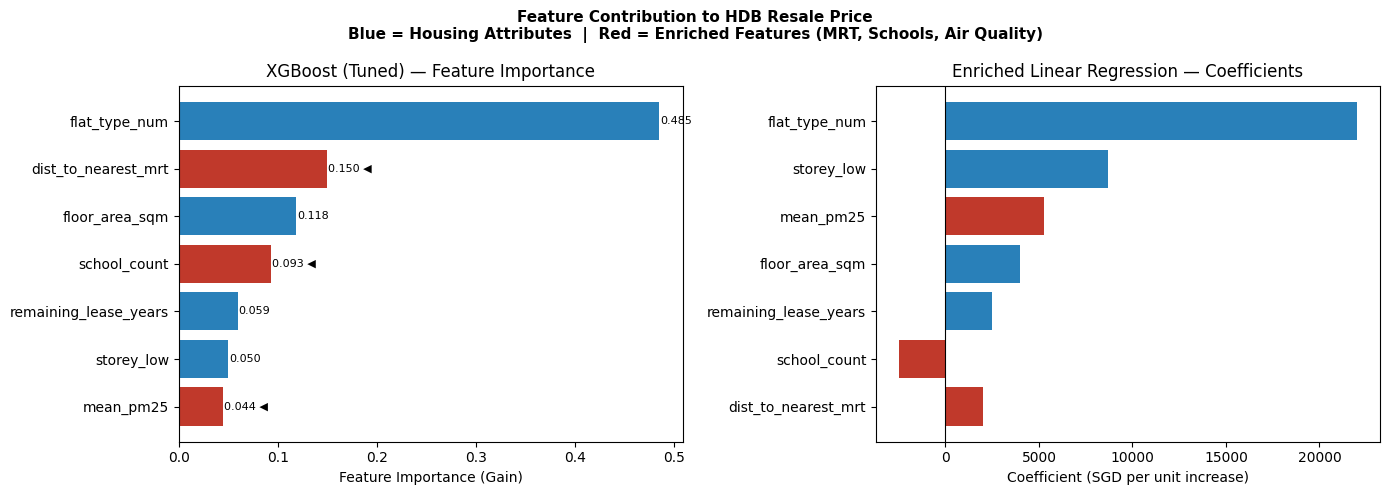

In [ ]:
feat_imp = pd.DataFrame({
    'Feature'  : enriched_features,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=True)

coef_df = pd.DataFrame({
    'Feature'    : enriched_features,
    'Coefficient': lr_enr.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

enriched_set = {'dist_to_nearest_mrt', 'school_count', 'mean_pm25'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost importance
colors_imp = ['#c0392b' if f in enriched_set else '#2980b9' for f in feat_imp['Feature']]
axes[0].barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp)
for i, (imp, feat) in enumerate(zip(feat_imp['Importance'], feat_imp['Feature'])):
    tag = ' ◀' if feat in enriched_set else ''
    axes[0].text(imp + 0.001, i, f'{imp:.3f}{tag}', va='center', fontsize=8)
axes[0].set_xlabel('Feature Importance (Gain)')
axes[0].set_title('XGBoost (Tuned) — Feature Importance')

# Linear coefficients
colors_coef = ['#c0392b' if f in enriched_set else '#2980b9' for f in coef_df['Feature']]
axes[1].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coefficient (SGD per unit increase)')
axes[1].set_title('Enriched Linear Regression — Coefficients')

plt.suptitle(
    'Feature Contribution to HDB Resale Price\n'
    'Blue = Housing Attributes  |  Red = Enriched Features (MRT, Schools, Air Quality)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

The positive coefficient on `dist_to_nearest_mrt` in the linear regression
model (+SGD 1,997 per km) appears counterintuitive — suggesting flats farther
from MRT are more expensive. This is likely a multicollinearity artefact: MRT
distance is computed at the town-centroid level, meaning some expensive central
towns (e.g., Bishan, Queenstown) happen to also have low centroid-to-MRT
distances, weakening the linear signal.

#### Part 13 — Actual vs Predicted Plots

We plot actual against predicted prices for the three main models. Points clustering tightly along the red diagonal line indicate accurate predictions. Systematic deviations reveal where each model struggles.

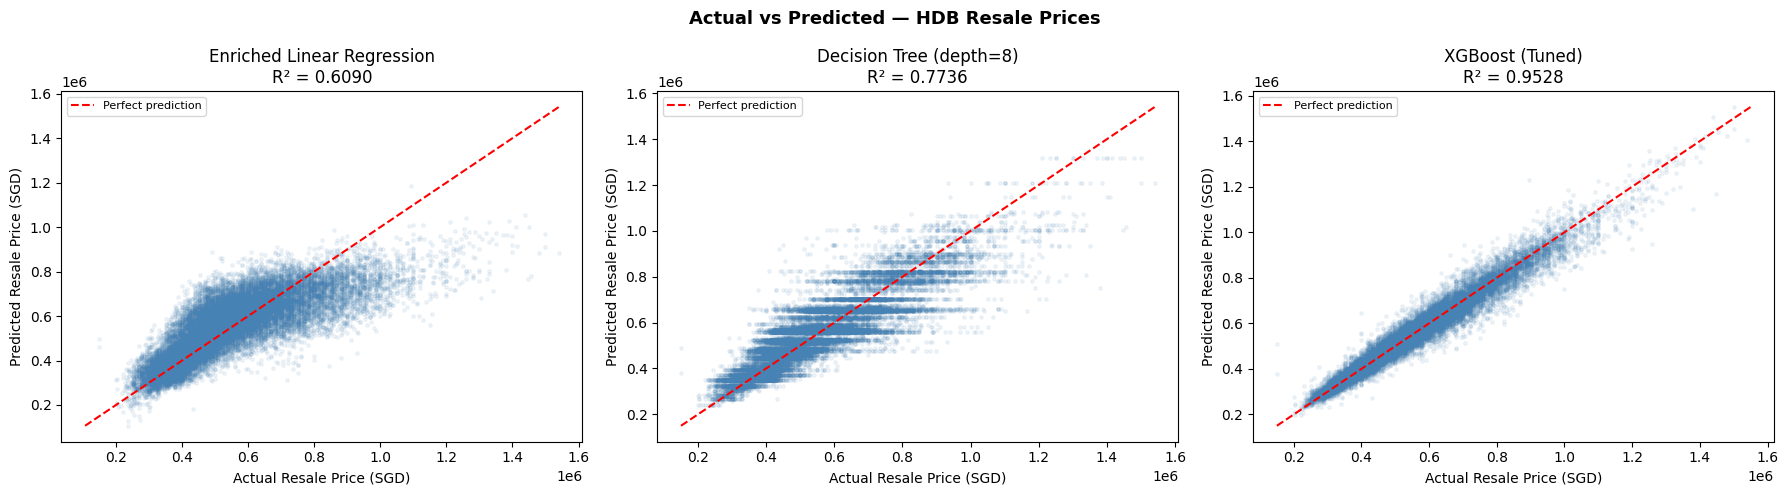

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, title, r2 in zip(
    axes,
    [y_pred_enr, y_pred_dt, y_pred_tuned],
    ['Enriched Linear Regression', 'Decision Tree (depth=8)', 'XGBoost (Tuned)'],
    [r2_enr, r2_dt, r2_tuned]
):
    ax.scatter(y_test, y_pred, alpha=0.08, s=6, color='steelblue')
    lims = [
        min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())
    ]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Resale Price (SGD)')
    ax.set_ylabel('Predicted Resale Price (SGD)')
    ax.set_title(f'{title}\nR² = {r2:.4f}')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — HDB Resale Prices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The actual vs predicted plots clearly illustrate the performance hierarchy. The linear regression (R²=0.609) shows considerable scatter around the diagonal, particularly at higher price ranges. The decision tree (R²=0.774) improves fit but exhibits a characteristic banding pattern.

The horizontal banding pattern in the Decision Tree plot is characteristic of tree-based models — because leaf nodes output a single constant value, predictions cluster at discrete levels corresponding to leaf node averages rather than forming a smooth continuum.

#### Part 14 — Residual Analysis

Residual analysis validates model assumptions and reveals patterns in prediction errors. We examine three views: residuals against predicted values (to check for heteroscedasticity), the overall residual distribution (to check normality), and residuals broken down by flat type (to check for systematic bias across flat categories).

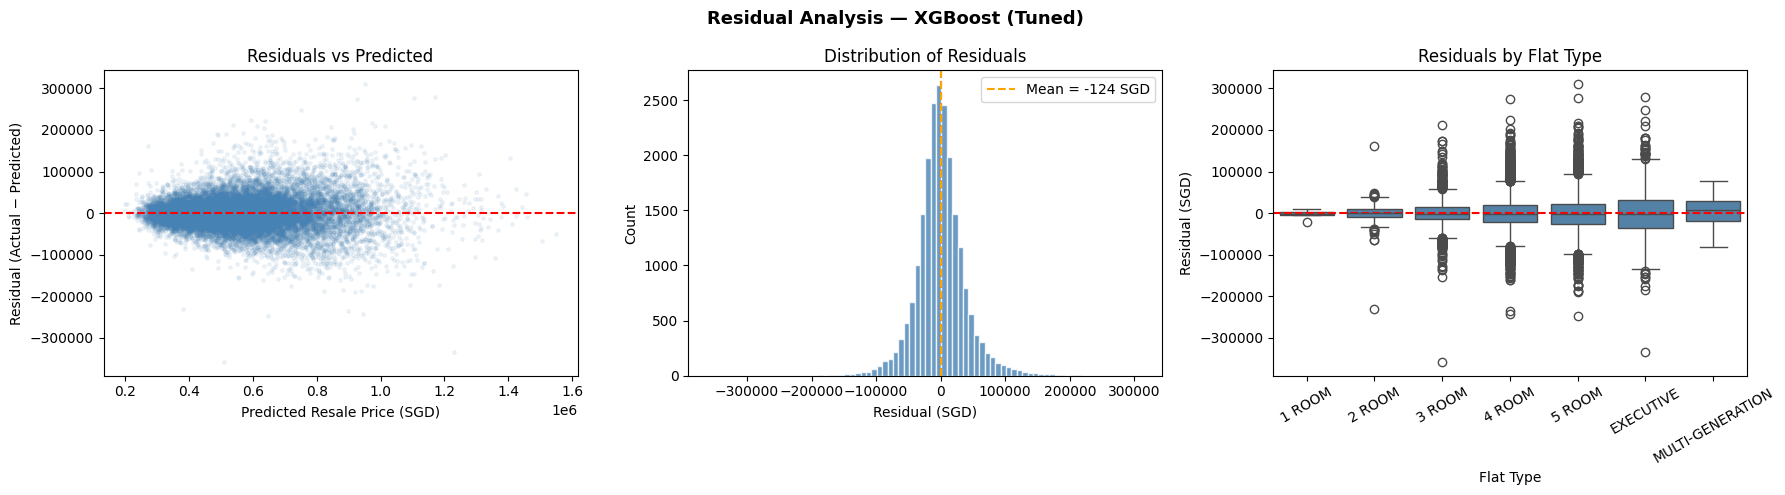

Residual Summary:
  Mean   :      -123.93 SGD
  Std    :    38,479.73 SGD
  Min    :  -357,735.41 SGD
  Max    :   309,975.62 SGD


In [ ]:
residuals = y_test - y_pred_tuned

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Residuals vs Predicted
axes[0].scatter(y_pred_tuned, residuals, alpha=0.08, s=6, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Resale Price (SGD)')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted')

# Plot 2: Residual Distribution
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean = {residuals.mean():,.0f} SGD')
axes[1].set_xlabel('Residual (SGD)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')
axes[1].legend()

# Plot 3: Residuals by Flat Type
df_resid = pd.DataFrame({
    'flat_type': df.loc[y_test.index, 'flat_type'],
    'residual' : residuals.values
})
order = ['1 ROOM','2 ROOM','3 ROOM','4 ROOM','5 ROOM','EXECUTIVE','MULTI-GENERATION']
order_present = [f for f in order if f in df_resid['flat_type'].unique()]
sns.boxplot(data=df_resid, x='flat_type', y='residual',
            order=order_present, ax=axes[2], color='steelblue')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Flat Type')
axes[2].set_ylabel('Residual (SGD)')
axes[2].set_title('Residuals by Flat Type')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Residual Analysis — XGBoost (Tuned)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Residual Summary:")
print(f"  Mean   : {residuals.mean():>12,.2f} SGD")
print(f"  Std    : {residuals.std():>12,.2f} SGD")
print(f"  Min    : {residuals.min():>12,.2f} SGD")
print(f"  Max    : {residuals.max():>12,.2f} SGD")

The residual analysis confirms the tuned XGBoost model is well-calibrated. The mean residual of SGD -124 is essentially zero, indicating no systematic over- or under-prediction on average.

The residuals vs predicted plot reveals a funnel-shaped pattern (heteroscedasticity) — residuals are tighter at lower price ranges and spread wider as predicted prices increase.
This heteroscedasticity suggests the model predicts lower-priced flats more precisely than premium flats — likely because premium transactions (executive, multi-generation flats in central areas) are more influenced by unique, unobserved factors such as specific block location, renovation quality, or negotiation premiums that are not captured in our feature set.The residual distribution is approximately bell-shaped and centred near zero, which is a positive sign.

The residuals-by-flat-type boxplot shows all flat types are centred around zero with no systematic bias. However, larger flat types (5 ROOM, EXECUTIVE, MULTI-GENERATION) show wider residual spread and more outliers.

**Interpretation**: Four models were tested. Linear regression (R² = 0.592) was the baseline. Adding MRT, school, and air quality features gave a slight bump (R² = 0.609). Non-linear models performed far better — Decision Tree hit R² = 0.774, and tuned XGBoost was the best at R² = 0.953 (RMSE: SGD 38,479), with no overfitting.

What Drives Prices?

* Flat type — by far the biggest factor (importance: 0.485). People pay for space.
* MRT distance — MRT distance ranks second in importance (0.150), above floor area alone (0.118) — noting that flat type already captures much of the size effect, so connectivity emerges as a genuinely strong independent price driver
* School count — moderate influence (0.093).
* Air quality (PM2.5) — least impactful (0.044), likely because Singapore's air quality doesn't vary much across regions.

**Limitations**: MRT distances use town centroids (not block addresses), air quality is region-level only, school counts are static, spatial autocorrelation isn't corrected for, and key amenities (malls, parks, hospitals) are excluded.

# **Presentation of main results (Share)**

## Stakeholders

1. Current homeowners: In the event they want to sell their house, they will have a clearing understanding on how to price their flats

2. Future homeowners: They will have a clearing understanding on which region and area of Singapore is within their budget and at the same time, having better air quality, rather than only understanding the adverse effects of poor air quality after moving in.

3. Property agents: With the knowledge, they can advice and recommend their clients the most suitable flat and also come up with better pricing stratgies.

4. Government agencies (policy makers and urban planners): Having the insights to better managed to air quality as well as the flat prices. For areas with extremely poor air quality, follow-up actions should be done to investigate and improve the surrounding environments

Anyone who is interested to learn about how air quality affects the housing prices, or in general for public who are keen to study about housing prices in Singapore

## Visualization

#### Visualisation 3 — Median Resale Price by Town (Year Filter)

In [ ]:
town_year = (
    df.groupby(['town', 'year', 'region'])['resale_price']
    .median()
    .reset_index()
    .rename(columns={'resale_price': 'median_price'})
)

region_colors = {
    'central'   : '#c0392b',
    'east'      : '#2980b9',
    'north'     : '#27ae60',
    'north-east': '#8e44ad',
    'west'      : '#e67e22'
}
town_year['color'] = town_year['region'].map(region_colors)

years = sorted(town_year['year'].unique())

fig0 = go.Figure()

# Add one trace per year AND per region (for proper legend)
for yr in years:
    subset = town_year[town_year['year'] == yr].sort_values('median_price', ascending=False)
    for region, color in region_colors.items():
        reg_subset = subset[subset['region'] == region]
        if reg_subset.empty:
            continue
        fig0.add_trace(go.Bar(
            x=reg_subset['town'],
            y=reg_subset['median_price'],
            name=region.title(),
            marker_color=color,
            visible=(yr == years[-1]),
            legendgroup=region,
            showlegend=bool(yr == years[-1]),  # only show legend for latest year
            hovertemplate=(
                '<b>%{x}</b><br>'
                'Median Price: SGD %{y:,.0f}<br>'
                f'Region: {region.title()}<extra></extra>'
            )
        ))

# Dropdown buttons
buttons = []
traces_per_year = len(region_colors)
for i, yr in enumerate(years):
    visible = []
    for j in range(len(years)):
        for _ in range(traces_per_year):
            visible.append(j == i)
    buttons.append(dict(
        label=str(yr),
        method='update',
        args=[
            {'visible': visible},
            {'title': f'Median HDB Resale Price by Town — {yr}'}
        ]
    ))

fig0.update_layout(
    title=f'Median HDB Resale Price by Town — {years[-1]}',
    title_font_size=14,
    xaxis_title='Town',
    yaxis_title='Median Resale Price (SGD)',
    xaxis_tickangle=-45,
    plot_bgcolor='white',
    height=520,
    barmode='group',
    legend=dict(
        title='Region',
        orientation='v',
        x=1.01,
        xanchor='left',
        y=1.0,
        yanchor='top',
        bgcolor='white',
        bordercolor='#cccccc',
        borderwidth=1
    ),
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.01,
        xanchor='left',
        y=1.12,
        yanchor='top',
        bgcolor='white',
        bordercolor='#cccccc'
    )],
    annotations=[dict(
        text='Select Year:',
        x=0.01, xref='paper',
        y=1.08, yref='paper',
        showarrow=False,
        font=dict(size=12)
    )]
)

fig0.show()

This interactive chart allows all stakeholders to explore how median HDB
resale prices differ across towns and have evolved over 2021–2024. Towns
are colour-coded by region for easy comparison. Use the dropdown to
switch between years.

**Key observations:**
- Central region towns (Queenstown, Bukit Timah, Bishan, Bukit Merah)
  consistently rank highest across all years, reflecting their proximity
  to the city centre and strong amenity access.
 - Prices have risen across all towns from 2021 to 2024, driven by
  post-COVID demand and tightened housing supply
- North and west region towns (Woodlands, Yishun, Jurong East, Bukit
  Batok) remain the most affordable options — offering future homeowners
  budget-friendly entry points while still maintaining reasonable MRT
  connectivity.
 -The widening price gap between central and non-central towns over the
  four years suggests growing spatial inequality in Singapore's resale
  market, which has implications for housing affordability policy.  

#### Visualisation 4 — Model Performance Comparison

**Regression Model Performance — R² and RMSE Across Four Models**

This chart compares the predictive performance of all four regression models built in the analysis stage.

In [ ]:
results_df = pd.DataFrame({
    'Model'     : ['Model 1: Baseline LR', 'Model 2: Enriched LR',
                   'Model 3: Decision Tree', 'Model 4: XGBoost (Tuned)'],
    'Features'  : ['Housing only', 'All features', 'All features', 'All features'],
    'R² (Test)' : [r2_base,   r2_enr,   r2_dt,   r2_tuned],
    'RMSE (SGD)': [rmse_base, rmse_enr, rmse_dt, rmse_tuned],
    'CV R²'     : [cv_base,   cv_enr,   cv_dt,   cv_tuned],
    'Color'     : ['#95a5a6', '#95a5a6', '#2980b9', '#c0392b']
})

fig1 = make_subplots(
    rows=1, cols=2,
    subplot_titles=('R² Score (Higher = Better)', 'RMSE in SGD (Lower = Better)')
)

fig1.add_trace(
    go.Bar(
        x=results_df['Model'],
        y=results_df['R² (Test)'],
        marker_color=results_df['Color'],
        text=[f"R²={v:.3f}" for v in results_df['R² (Test)']],
        textposition='outside',
        name='R²',
        hovertemplate='<b>%{x}</b><br>R² = %{y:.4f}<extra></extra>'
    ), row=1, col=1
)

fig1.add_trace(
    go.Bar(
        x=results_df['Model'],
        y=results_df['RMSE (SGD)'],
        marker_color=results_df['Color'],
        text=[f"SGD {v:,.0f}" for v in results_df['RMSE (SGD)']],
        textposition='outside',
        name='RMSE',
        hovertemplate='<b>%{x}</b><br>RMSE = SGD %{y:,.0f}<extra></extra>'
    ), row=1, col=2
)

fig1.update_layout(
    title_text='Regression Model Performance Comparison — R² and RMSE Across Four Models',
    title_font_size=14,
    showlegend=False,
    plot_bgcolor='white',
    height=450,
    xaxis=dict(tickangle=-20),
    xaxis2=dict(tickangle=-20)
)
fig1.update_yaxes(range=[0, 1.12], row=1, col=1)
fig1.show()

This chart compares the predictive accuracy of all four models built in
our analysis, allowing stakeholders to understand how well HDB resale
prices can be predicted and what drives model improvement.

**Key observations:**
- The baseline linear model (housing attributes only) achieves R² = 0.592,
  meaning housing size, storey, lease, and flat type alone explain about
  59% of price variation.
- Adding MRT distance, school count, and air quality (Model 2) improves
  R² to 0.609 — a modest but meaningful gain, confirming that
  environmental and accessibility features contribute beyond housing
  attributes alone.
- The jump to non-linear models is far more significant: the Decision Tree
  (R² = 0.774) and tuned XGBoost (R² = 0.953, RMSE = SGD 38,479)
  substantially outperform linear models, revealing that price
  relationships are highly non-linear in nature.
- The tuned XGBoost model's near-identical test R² (0.953) and CV R²
  (0.951) confirms there is no overfitting — predictions generalise well
  to unseen transactions.



#### Visualisation 5 — Feature Importance

**What Drives HDB Resale Prices? — XGBoost Feature Importance**

This chart directly answers our core research question by showing the relative contribution of each feature in the tuned XGBoost model.

In [ ]:
feat_imp_df = pd.DataFrame({
    'Feature'   : ['Flat Type', 'MRT Distance ◀', 'Floor Area (sqm)',
                   'School Count ◀', 'Remaining Lease', 'Storey Level',
                   'Air Quality PM2.5 ◀'],
    'Importance': [0.485, 0.150, 0.118, 0.093, 0.059, 0.050, 0.044],
    'Category'  : ['Housing Attribute', 'Enriched Feature', 'Housing Attribute',
                   'Enriched Feature', 'Housing Attribute', 'Housing Attribute',
                   'Enriched Feature']
}).sort_values('Importance', ascending=True)

color_map = {
    'Housing Attribute': '#2980b9',
    'Enriched Feature' : '#c0392b'
}

fig2 = px.bar(
    feat_imp_df,
    x='Importance',
    y='Feature',
    color='Category',
    color_discrete_map=color_map,
    orientation='h',
    text='Importance',
    title='What Drives HDB Resale Prices? — XGBoost (Tuned) Feature Importance',
    labels={'Importance': 'Importance Score (Gain)', 'Feature': ''}
)

fig2.update_traces(
    texttemplate='%{text:.3f}',
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Importance = %{x:.3f}<extra></extra>'
)
fig2.update_xaxes(range=[0, 0.55])

fig2.update_layout(
    plot_bgcolor='white',
    height=420,
    legend_title_text='Feature Category',
    title_font_size=14,
    legend=dict(
    title='Feature Category',
    x=1.0,
    xanchor='left',
    y=0.5
),
margin=dict(r=180)   # give legend more right space
)
fig2.show()

This chart directly answers our core research question by showing the
relative contribution of each feature in predicting HDB resale prices.
Red bars represent our enriched features (MRT distance, school count,
air quality); blue bars represent baseline housing attributes.

Key observations:
- Flat type dominates with an importance score of 0.485 — buyers pay
  primarily for space, making it the single strongest price signal.
- MRT distance ranks second in importance (0.150), above floor area
  (0.118) — confirming that proximity to MRT stations is a key factor
  in determining resale price.
- Our correlation analysis shows a negative
  relationship between MRT distance and price (farther = cheaper),
  consistent with our hypothesis.
- owever, the linear regression
  coefficient for this feature was unexpectedly positive, likely due to
  multicollinearity at the town-centroid level — XGBoost handles this
  more robustly by capturing the non-linear relationship directly
- The feature importance score therefore reflects that MRT distance
  genuinely matters to price, even if the precise direction is better
  interpreted from the correlation analysis than the linear coefficients.

#**Possible actions based on results (Act)**

Based on our analysis findings, we recommend the following data-driven
actions for each stakeholder group:



**1. Current Homeowners**

When pricing a flat for sale, homeowners should factor in MRT proximity
as a key value driver. Our analysis shows it is the second most important
price predictor (importance: 0.150), ranking above floor area alone.
Homeowners in towns with strong MRT connectivity (e.g., Bishan, Queenstown,
Tampines) can justify pricing at a premium relative to comparable flats in
less connected towns. Conversely, homeowners in towns farther from MRT
stations should set realistic expectations and consider highlighting other
selling points such as school proximity (importance: 0.093) or remaining
lease years to justify their asking price.

**2. Future Homeowners**

Aspiring homeowners should evaluate towns holistically rather than
focusing on any single factor. Our model confirms that flat type and
size remain the dominant price drivers.Buyers on a budget may find
better value by opting for a slightly smaller flat in a well-connected
town than a larger flat in a poorly connected area.

**3. Property Agents**

Agents can use our feature importance findings to build more data-driven
pricing strategies. Specifically: highlight MRT proximity and flat type
as the primary value anchors in listings; use school count as a secondary
selling point for family-oriented buyers; and avoid over-emphasising air
quality as a price justification given its currently weak direct effect
(importance: 0.044).

**4. Government Agencies (Policymakers and Urban Planners)**

Two actionable priorities emerge from our analysis. First, the strong
MRT proximity price premium (2nd most important feature overall)
reinforces the case for expanding rail coverage to underserved towns
particularly in the north and west regions where median prices are lowest
and MRT distances are greatest. Improving connectivity in these areas
would not only enhance liveability but also support more equitable wealth
accumulation for residents.

**5. General Public**

For anyone interested in understanding Singapore's HDB resale market,
our analysis demonstrates that housing prices are driven by a combination
of factors that go beyond simple flat size. Connectivity (MRT access) and
education infrastructure (school count) meaningfully contribute to price
variation, while environmental quality (air quality) plays a currently
modest but potentially growing role as public awareness of health impacts
increases. The interactive visualisations in **Share section** provide
an accessible starting point for exploring price trends across towns and
years without requiring any technical background.

# Final Reflection

## Considerations on data ethics

Our analysis uses publicly available datasets from data.gov.sg and NEA, which were originally collected for administrative and environmental monitoring, not for predicting housing prices. Using this data for a different purpose raises ethical concerns about whether it is being applied in a way that matches its original intent. For example, our model estimates how much MRT access and the number of nearby schools are associated with higher resale prices. These insights could be misused by property agents or developers to justify higher prices in towns that are still relatively affordable, which may contribute to gentrification and make housing less accessible for lower-income households.

We also recognise that our model is based on correlations. We cannot conclude that being close to an MRT station directly causes prices to increase, and presenting the results without this explanation may mislead non-technical readers. In addition, our school count feature treats all schools the same, without considering differences in reputation or demand. This simplification may introduce bias into our accessibility measure and underestimate the impact of proximity to more popular schools.

## Considerations on data privacy and security

The HDB resale dataset contains transaction-level information including block number, street name, flat type, and transaction month. It does not contain personal identifiers such as names or NRIC numbers. However, combining these fields may still allow re-identification in edge cases, for example in towns with very few transactions or for rare flat types in a particular month. Our geospatial enrichment step, where town centroids were joined with nearby MRT stations and schools, adds further locational detail and increases this risk. To mitigate it, we ensured that all individual-level data remained internal to the team and that our analysis was based only on aggregated or anonymised results. Looking ahead, applying differential privacy or using more aggregated data would further strengthen privacy protections before any public deployment.